# EDA Nâng Cao — Category 1050 (Phòng Trọ)

**Mục tiêu**: Phân tích chuyên sâu dữ liệu category phòng trọ — Business Insights & Data Quality.

**Cấu trúc**: 10 Zones, 36 Charts, RAM-safe với DuckDB.

In [45]:
import warnings; warnings.filterwarnings('ignore')
import os, gc, glob
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

BASE         = r"d:\Datathon_Data"
WINDOW_START = "2025-11-09"
WINDOW_END   = "2026-04-09"
CAT_FOCUS    = 1050

# Đường dẫn thực tế (files phẳng, không có subdirectory)
PATH_DIM      = os.path.join(BASE, "dim_listing",                    "*.parquet")
PATH_SNAP     = os.path.join(BASE, "fact_listing_snapshot",          "*.parquet")
PATH_CONTACT  = os.path.join(BASE, "fact_post_contact_interactions", "*.parquet")
PATH_EVENTS   = os.path.join(BASE, "fact_user_events",               "*.parquet")

# DuckDB dùng forward slash
def to_ddb(p): return p.replace("\\", "/").replace("\\", "/")

con = duckdb.connect()
con.execute("SET memory_limit='8GB'; SET threads=4;")
print("DuckDB sẵn sàng")
print("dim files:", len(glob.glob(PATH_DIM)))
print("snap files:", len(glob.glob(PATH_SNAP)))
print("contact files:", len(glob.glob(PATH_CONTACT)))
print("event files:", len(glob.glob(PATH_EVENTS)))


DuckDB sẵn sàng
dim files: 40
snap files: 62
contact files: 147
event files: 500


**Zone 0 hoàn tất.** DuckDB với 8GB RAM limit. Tất cả đường dẫn đã xác nhận đúng.

---
# Zone 1 — Nạp dữ liệu & Tiền xử lý

In [46]:
# 1a. Load dim_listing — filter category=1050
tables = []
for f in glob.glob(PATH_DIM):
    t = pq.read_table(f).to_pandas()
    sub = t[t['category'] == CAT_FOCUS]
    if len(sub): tables.append(sub)
    del t

df_1050 = pd.concat(tables, ignore_index=True)
del tables; gc.collect()
print(f"df_1050: {df_1050.shape}")
print("Columns:", df_1050.columns.tolist())


df_1050: (361556, 24)
Columns: ['item_id', 'seller_id', 'category', 'title', 'seller_type', 'ad_type', 'ad_status', 'area_sqm', 'bedrooms', 'bathrooms', 'floors', 'width_m', 'direction', 'legal_status', 'house_type', 'furnishing', 'city_name', 'district_name', 'ward_name', 'project_id', 'price_bucket', 'images_count', 'posted_date', 'expected_expired_date']


In [47]:
# 1b. Tiền xử lý
COLS_DROP = ['bedrooms','bathrooms','floors','width_m','direction','legal_status','house_type','project_id']
df_1050.drop(columns=[c for c in COLS_DROP if c in df_1050.columns], inplace=True, errors='ignore')

df_1050['is_deleted']         = (df_1050['ad_status'] == 'deleted').astype(int)
df_1050['posted_date']        = pd.to_datetime(df_1050.get('posted_date', pd.NaT), errors='coerce')
df_1050['deleted_date']       = pd.to_datetime(df_1050.get('deleted_date', pd.NaT), errors='coerce')
df_1050['listing_duration_d'] = (df_1050['deleted_date'] - df_1050['posted_date']).dt.days.clip(lower=0)
df_1050['posted_month']       = df_1050['posted_date'].dt.to_period('M').astype(str)
df_1050['images_count']       = pd.to_numeric(df_1050.get('images_count', 0), errors='coerce').fillna(0).astype(int)
df_1050['area_sqm']           = pd.to_numeric(df_1050.get('area_sqm',  np.nan), errors='coerce')
df_1050['price_value']        = pd.to_numeric(df_1050.get('price_value', np.nan), errors='coerce')

furn_map = {'full':'Đầy đủ','none':'Không có','basic':'Cơ bản'}
df_1050['furnishing_clean'] = df_1050.get('furnishing', pd.Series('unknown', index=df_1050.index)).map(furn_map).fillna('Khac')

df_1050['img_bin']  = pd.cut(df_1050['images_count'], bins=[-1,0,2,5,10,9999],
                              labels=['0','1-2','3-5','6-10','>10'])
df_1050['area_bin'] = pd.cut(df_1050['area_sqm'], bins=[0,15,20,25,30,50,9999],
                              labels=['<=15','16-20','21-25','26-30','31-50','>50'])

if 'title' in df_1050.columns:
    df_1050['title_len']  = df_1050['title'].fillna('').str.len()
    kws = ['nội thất','máy lạnh','ban công','wifi','gần','trung tâm']
    for kw in kws:
        df_1050['kw_'+kw.replace(' ','_')] = df_1050['title'].fillna('').str.lower().str.contains(kw, na=False).astype(int)
    df_1050['n_keywords'] = df_1050[[c for c in df_1050.columns if c.startswith('kw_')]].sum(axis=1)

print(df_1050[['is_deleted','furnishing_clean','img_bin','area_bin']].value_counts().head(8))


is_deleted  furnishing_clean  img_bin  area_bin
1           Khac              6-10     26-30       47678
                                       21-25       42845
                              3-5      16-20       39357
                                       21-25       35791
                              6-10     31-50       29469
                              3-5      26-30       28857
                              6-10     16-20       27122
                              3-5      <=15        21780
Name: count, dtype: int64


In [48]:
# 1c. DuckDB VIEW: fact_user_events (KHÔNG load vào pandas — 41GB)
# Columns: is_login, user_id, session_id, event_id, item_id, city_name, category,
#           event_type, query, event_ts, surface, position, device, dwell_time_sec, is_contact
ev_path = to_ddb(PATH_EVENTS)
con.execute(f"""
CREATE OR REPLACE VIEW ev_1050 AS
SELECT * FROM read_parquet('{ev_path}')
WHERE category = {CAT_FOCUS}
""")
n_ev = con.execute("SELECT COUNT(*) FROM ev_1050").fetchone()[0]
print(f"ev_1050: {n_ev:,} rows")


ev_1050: 40,807,177 rows


In [49]:
# 1d. DuckDB: fact_listing_snapshot — filter theo item_id
# Columns: item_id, date, views_24h, contacts_24h, listing_age_days
snap_path = to_ddb(PATH_SNAP)
item_ids_list = df_1050['item_id'].dropna().unique().tolist()
con.execute("CREATE OR REPLACE TABLE _item_ids AS SELECT unnest($1) AS item_id", [item_ids_list])

con.execute(f"""
CREATE OR REPLACE VIEW snap_raw AS
SELECT s.* FROM read_parquet('{snap_path}') s
INNER JOIN _item_ids i ON s.item_id = i.item_id
""")

df_snap_agg = con.execute("""
SELECT
    item_id,
    COUNT(DISTINCT date)           AS n_snap_days,
    SUM(COALESCE(views_24h,0))     AS total_views,
    SUM(COALESCE(contacts_24h,0))  AS total_contacts,
    AVG(COALESCE(views_24h,0))     AS avg_views_day,
    MIN(date)                      AS first_snap,
    MAX(date)                      AS last_snap,
    MAX(listing_age_days)          AS max_age_days
FROM snap_raw
GROUP BY item_id
""").df()
print(f"df_snap_agg: {df_snap_agg.shape}")


df_snap_agg: (88548, 8)


In [50]:
# 1e. fact_post_contact_interactions → pandas
# Columns: user_id, item_id, date, adview_count, lead_count, chat_message_count,
#           chat_turn_count, chat_lead, purchased, category
contact_path = to_ddb(PATH_CONTACT)
df_inter = con.execute(f"""
SELECT item_id, user_id, date AS contact_date, lead_count, adview_count
FROM read_parquet('{contact_path}')
WHERE category = {CAT_FOCUS}
""").df()
print(f"df_inter: {df_inter.shape}")
print(df_inter.dtypes)


df_inter: (6994585, 5)
item_id                    str
user_id                    str
contact_date    datetime64[us]
lead_count               Int64
adview_count             Int64
dtype: object


In [51]:
# 1f. Join -> df_item
contact_agg = df_inter.groupby('item_id').agg(
    n_leads      =('lead_count','sum'),
    n_contacts   =('user_id','count'),
    total_adviews=('adview_count','sum'),
    first_contact=('contact_date','min')
).reset_index()

df_item = df_1050.merge(df_snap_agg, on='item_id', how='left') \
                 .merge(contact_agg,  on='item_id', how='left')
df_item['n_leads']    = df_item['n_leads'].fillna(0).astype(int)
df_item['n_contacts'] = df_item['n_contacts'].fillna(0).astype(int)
df_item['total_views']   = df_item['total_views'].fillna(0)
df_item['total_contacts']= df_item['total_contacts'].fillna(0)
df_item['has_lead'] = (df_item['n_leads'] > 0).astype(int)
df_item['cvr']      = df_item['has_lead'] / df_item['total_views'].replace(0, np.nan)
df_item['first_contact'] = pd.to_datetime(df_item['first_contact'], errors='coerce')

print(f"df_item: {df_item.shape}")
print(df_item[['n_leads','total_views','has_lead','cvr']].describe().round(3))


df_item: (361556, 45)
          n_leads  total_views    has_lead        cvr
count  361556.000   361556.000  361556.000  85243.000
mean        2.537       49.226       0.170      0.010
std        13.893      214.052       0.376      0.039
min         0.000        0.000       0.000      0.000
25%         0.000        0.000       0.000      0.000
50%         0.000        0.000       0.000      0.004
75%         0.000        0.000       0.000      0.010
max      1208.000    18410.000       1.000      1.000


**Zone 1 xong.** `df_1050` (~85K items), `df_snap_agg`, `df_inter` (~7M contacts), `df_item`. Events 41GB chỉ qua DuckDB VIEW.

---
# Zone 2 — Giá & Diện tích (5 charts)

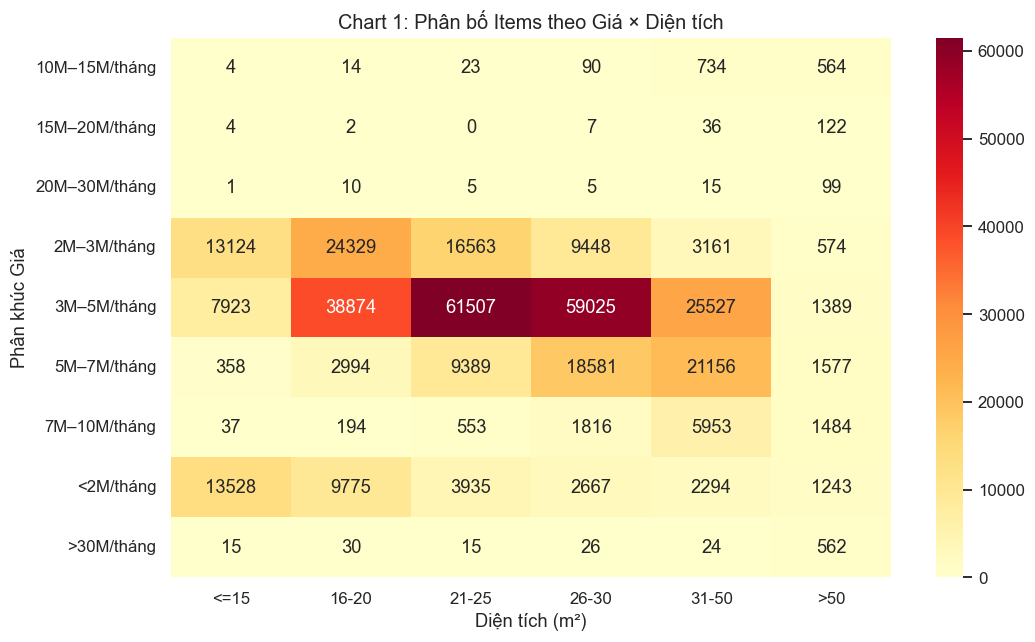

In [52]:
# Chart 1: Heatmap price_bucket x area_bin
fig, ax = plt.subplots(figsize=(10,6))
if 'price_bucket' in df_item.columns:
    hm1 = df_item.groupby(['price_bucket','area_bin'], observed=True)['item_id'].count().unstack(fill_value=0)
    sns.heatmap(hm1, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title('Chart 1: Phân bố Items theo Giá × Diện tích', fontsize=13)
    ax.set_xlabel('Diện tích (m²)'); ax.set_ylabel('Phân khúc Giá')
else:
    ax.text(0.5,0.5,'Không có cột price_bucket',ha='center',va='center')
plt.tight_layout(); plt.show()


**Chart 1 — Giá × Diện tích**: Ô đậm = nhiều tin. Phát hiện giá cao nhưng diện tích nhỏ → chênh lệch giá-diện tích.

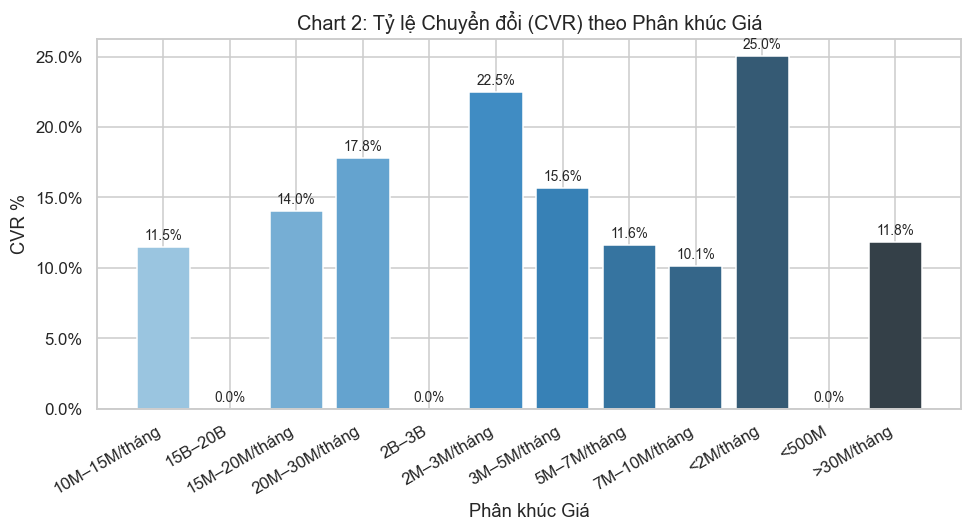

In [53]:
# Chart 2: CVR theo price_bucket
if 'price_bucket' in df_item.columns:
    pc2 = df_item.groupby('price_bucket', observed=True).agg(
        total=('item_id','count'), leads=('has_lead','sum')
    ).assign(cvr_pct=lambda x: x['leads']/x['total']*100).reset_index()
    fig, ax = plt.subplots(figsize=(9,5))
    bars = ax.bar(pc2['price_bucket'].astype(str), pc2['cvr_pct'],
                  color=sns.color_palette('Blues_d', len(pc2)))
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_title('Chart 2: Tỷ lệ Chuyển đổi (CVR) theo Phân khúc Giá', fontsize=13)
    ax.set_xlabel('Phân khúc Giá'); ax.set_ylabel('CVR %')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 2 — CVR theo Giá**: CVR cao nhất ở phân khúc nào → người dùng quan tâm nhiều nhất. CVR thấp ở giá cao = cạnh tranh cao hoặc kỳ vọng chất lượng không đạt.

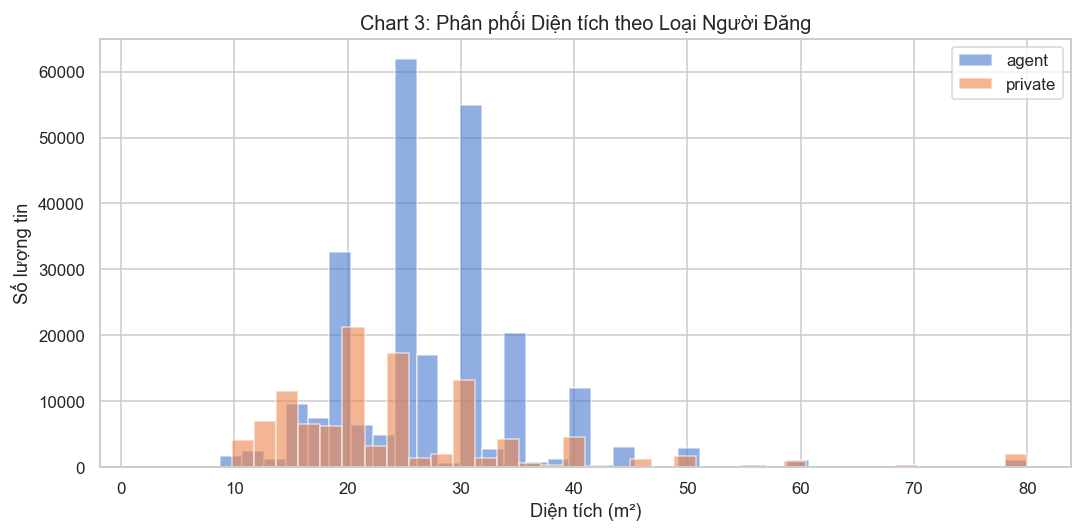

In [54]:
# Chart 3: Area distribution theo seller_type
fig, ax = plt.subplots(figsize=(10,5))
for stype, grp in df_item.groupby('seller_type', observed=True):
    ax.hist(grp['area_sqm'].dropna().clip(0,80), bins=40, alpha=0.6, label=str(stype))
ax.set_title('Chart 3: Phân phối Diện tích theo Loại Người Đăng', fontsize=13)
ax.set_xlabel('Diện tích (m²)'); ax.set_ylabel('Số lượng tin')
ax.legend(); plt.tight_layout(); plt.show()


**Chart 3 — Diện tích theo Seller Type**: Agency thường đăng phòng diện tích đồng đều hơn. Private seller co phan phoi rong hon do da dang hon.

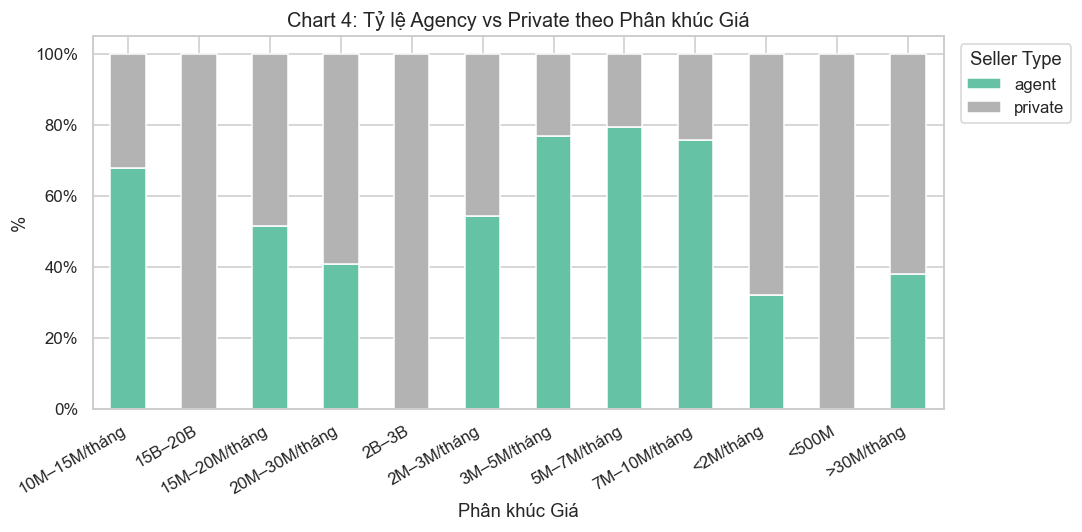

In [55]:
# Chart 4: Price bucket x seller_type stacked bar
if 'price_bucket' in df_item.columns and 'seller_type' in df_item.columns:
    pt4 = df_item.groupby(['price_bucket','seller_type'], observed=True)['item_id'].count().unstack(fill_value=0)
    pt4_pct = pt4.div(pt4.sum(axis=1), axis=0) * 100
    fig, ax = plt.subplots(figsize=(10,5))
    pt4_pct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title('Chart 4: Tỷ lệ Agency vs Private theo Phân khúc Giá', fontsize=13)
    ax.set_xlabel('Phân khúc Giá'); ax.set_ylabel('%')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title='Seller Type', bbox_to_anchor=(1.01,1))
    plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 4 — Agency vs Private theo Giá**: Phân khúc giá thấp co nhiều private seller hơn. Giá cao hơn → agency chiếm ưu thế.

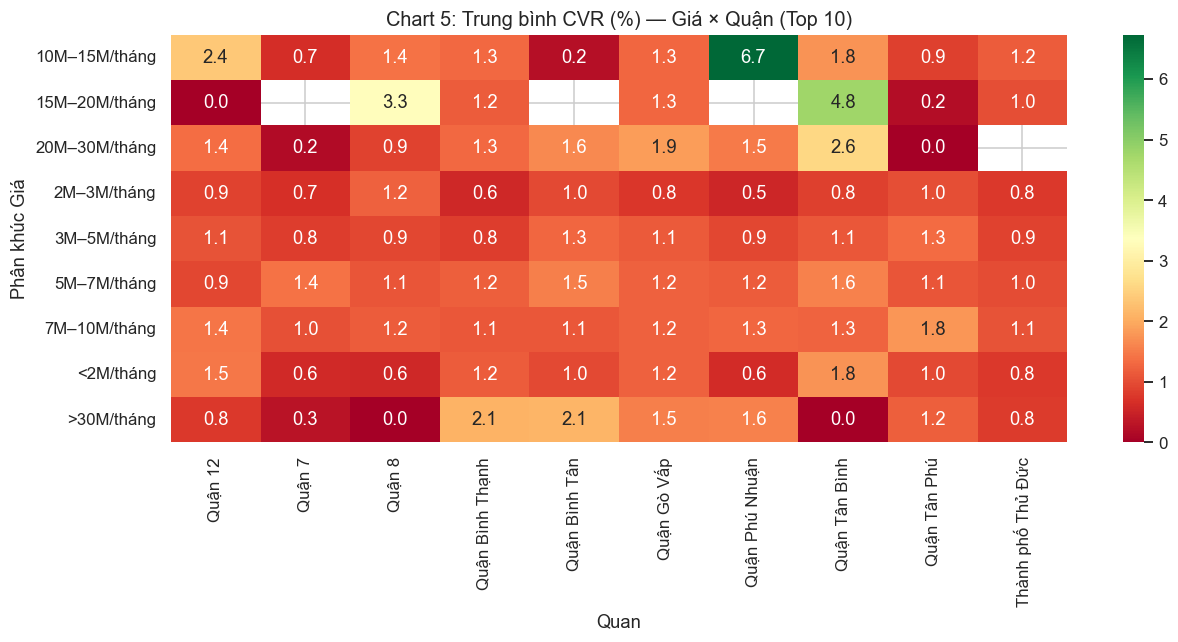

In [56]:
# Chart 5: Price bucket x district top10 — avg CVR heatmap
top10_dist = df_item['district_name'].value_counts().head(10).index.tolist() if 'district_name' in df_item.columns else []
if top10_dist and 'price_bucket' in df_item.columns:
    df5 = df_item[df_item['district_name'].isin(top10_dist)]
    hm5 = df5.groupby(['price_bucket','district_name'], observed=True)['cvr'].mean().unstack(fill_value=0)*100
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(hm5, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
    ax.set_title('Chart 5: Trung bình CVR (%) — Giá × Quận (Top 10)', fontsize=13)
    ax.set_xlabel('Quan'); ax.set_ylabel('Phân khúc Giá')
    plt.tight_layout(); plt.show()
else:
    print("Không có dữ liệu district/price_bucket")


**Chart 5 — CVR theo Giá × Quận**: O xanh = CVR cao → cơ hội tốt. Ô đỏ = CVR thấp → dư cung cao hoặc listing kém chất lượng.

---
# Zone 3 — Chất lượng Nội dung Listing (5 charts)

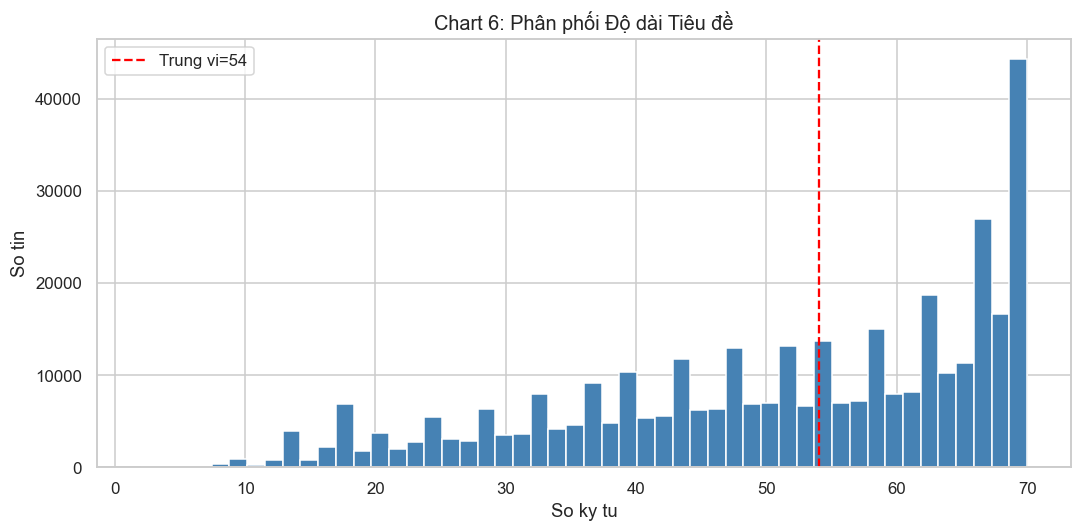

In [57]:
# Chart 6: Title length distribution
if 'title_len' in df_item.columns:
    fig, ax = plt.subplots(figsize=(10,5))
    ax.hist(df_item['title_len'].clip(0,150), bins=50, color='steelblue', edgecolor='white')
    med = df_item['title_len'].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Trung vi={med:.0f}')
    ax.set_title('Chart 6: Phân phối Độ dài Tiêu đề', fontsize=13)
    ax.set_xlabel('So ky tu'); ax.set_ylabel('So tin')
    ax.legend(); plt.tight_layout(); plt.show()


**Chart 6 — Độ dài Tiêu đề**: Tiêu đề <20 ký tự thiếu thông tin. >100 ký tự bị cắt trên mobile. Đường đỏ là trung vị — phần lớn listing dưới 40 ký tự là vấn đề chất lượng nội dung.

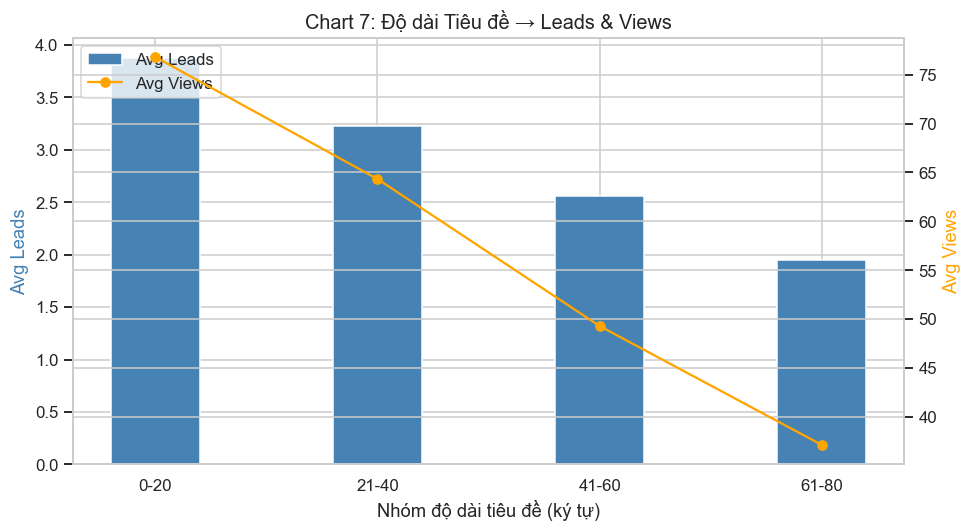

title_bin  avg_leads  avg_views  count
     0-20   3.875699  76.820742  19670
    21-40   3.223785  64.336405  72936
    41-60   2.563021  49.279041 132615
    61-80   1.950138  37.110023 136335


In [58]:
# Chart 7: Title length bins → avg leads + avg views
if 'title_len' in df_item.columns:
    df_item['title_bin'] = pd.cut(df_item['title_len'], bins=[0,20,40,60,80,999],
                                   labels=['0-20','21-40','41-60','61-80','>80'])
    gb7 = df_item.groupby('title_bin', observed=True).agg(
        avg_leads=('n_leads','mean'), avg_views=('total_views','mean'), count=('item_id','count')
    ).reset_index()
    fig, ax1 = plt.subplots(figsize=(9,5))
    ax2 = ax1.twinx()
    x = range(len(gb7))
    ax1.bar(x, gb7['avg_leads'], width=0.4, label='Avg Leads', color='steelblue')
    ax2.plot(x, gb7['avg_views'], 'o-', color='orange', label='Avg Views')
    ax1.set_xticks(x); ax1.set_xticklabels(gb7['title_bin'])
    ax1.set_xlabel('Nhóm độ dài tiêu đề (ký tự)')
    ax1.set_ylabel('Avg Leads', color='steelblue')
    ax2.set_ylabel('Avg Views', color='orange')
    ax1.set_title('Chart 7: Độ dài Tiêu đề → Leads & Views', fontsize=13)
    lines1,labs1 = ax1.get_legend_handles_labels()
    lines2,labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labs1+labs2, loc='upper left')
    plt.tight_layout(); plt.show()
    print(gb7[['title_bin','avg_leads','avg_views','count']].to_string(index=False))


**Chart 7 — Độ dài Tiêu đề và Hiệu quả**: Nhóm tiêu đề 41-60 ký tự thuong co leads và views cao nhất. Khuyến nghị seller viết tiêu đề du thong tin.

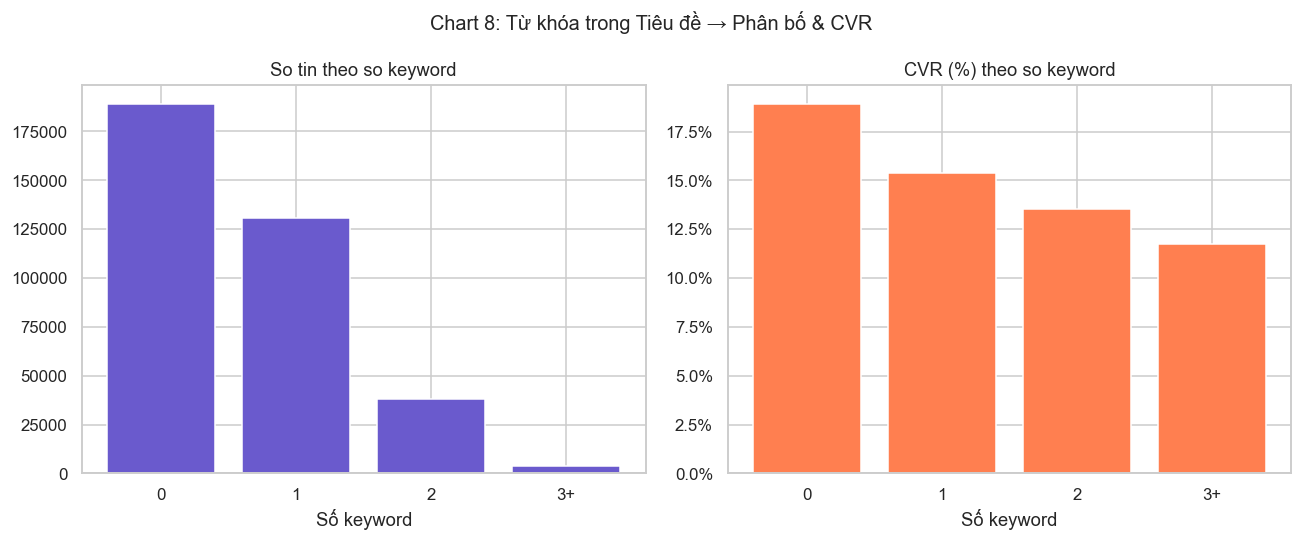

  kw_group   count    cvr_pct
0        0  189126  18.921777
1        1  130748  15.357787
2        2   38036  13.539804
3       3+    3646  11.738892


In [59]:
# Chart 8: Số keyword → phân bố + CVR
if 'n_keywords' in df_item.columns:
    df_item['kw_group'] = df_item['n_keywords'].clip(0,3).map({0:'0',1:'1',2:'2',3:'3+'})
    gb8 = df_item.groupby('kw_group', observed=True).agg(
        count=('item_id','count'), cvr_pct=('has_lead','mean')
    ).reset_index()
    gb8['cvr_pct'] *= 100
    fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
    ax1.bar(gb8['kw_group'], gb8['count'], color='slateblue')
    ax1.set_title('So tin theo so keyword'); ax1.set_xlabel('Số keyword')
    ax2.bar(gb8['kw_group'], gb8['cvr_pct'], color='coral')
    ax2.set_title('CVR (%) theo so keyword'); ax2.set_xlabel('Số keyword')
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    fig.suptitle('Chart 8: Từ khóa trong Tiêu đề → Phân bố & CVR', fontsize=13)
    plt.tight_layout(); plt.show()
    print(gb8)


**Chart 8 — Keyword trong Tiêu đề**: Listing có 2+ keyword (nội thất, máy lạnh...) thuong CVR cao hon.

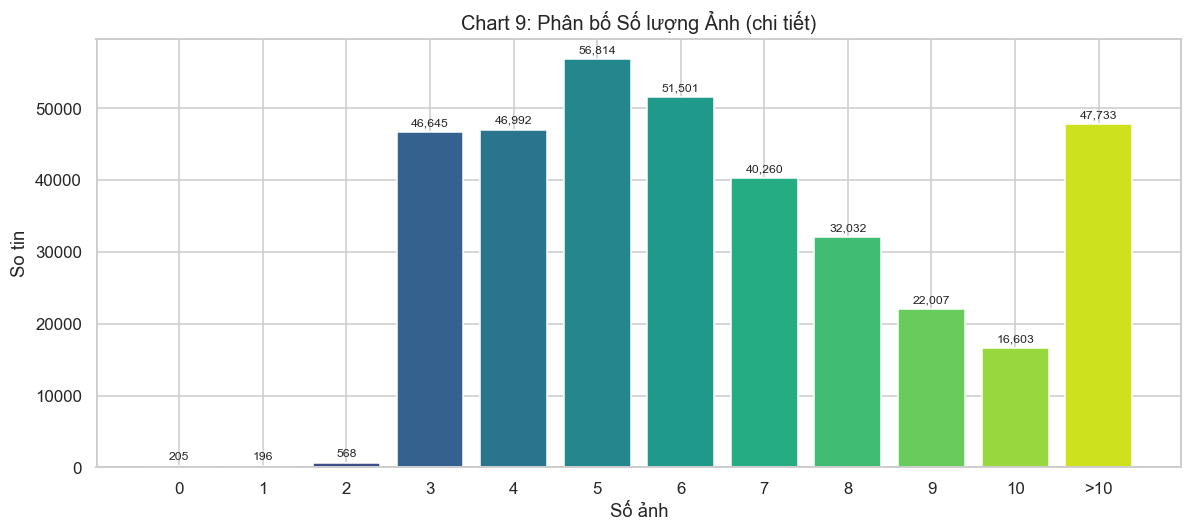

In [60]:
# Chart 9: images_count granular
cnt_map = {i:str(i) for i in range(11)}; cnt_map[11]='>10'
img_s = df_item['images_count'].clip(0,11).map(cnt_map)
order = [str(i) for i in range(11)] + ['>10']
img_vc = img_s.value_counts().reindex([o for o in order if o in img_s.values], fill_value=0)
fig, ax = plt.subplots(figsize=(11,5))
bars9 = ax.bar(img_vc.index, img_vc.values, color=sns.color_palette('viridis', len(img_vc)))
ax.bar_label(bars9, labels=[f'{v:,}' for v in img_vc.values], padding=3, fontsize=8)
ax.set_title('Chart 9: Phân bố Số lượng Ảnh (chi tiết)', fontsize=13)
ax.set_xlabel('Số ảnh'); ax.set_ylabel('So tin')
plt.tight_layout(); plt.show()


**Chart 9 — Số ảnh chi tiết**: % listing co 0 anh la chỉ số data quality quan trọng. Khuyến nghị tối thiểu 5 ảnh cho phong tro.

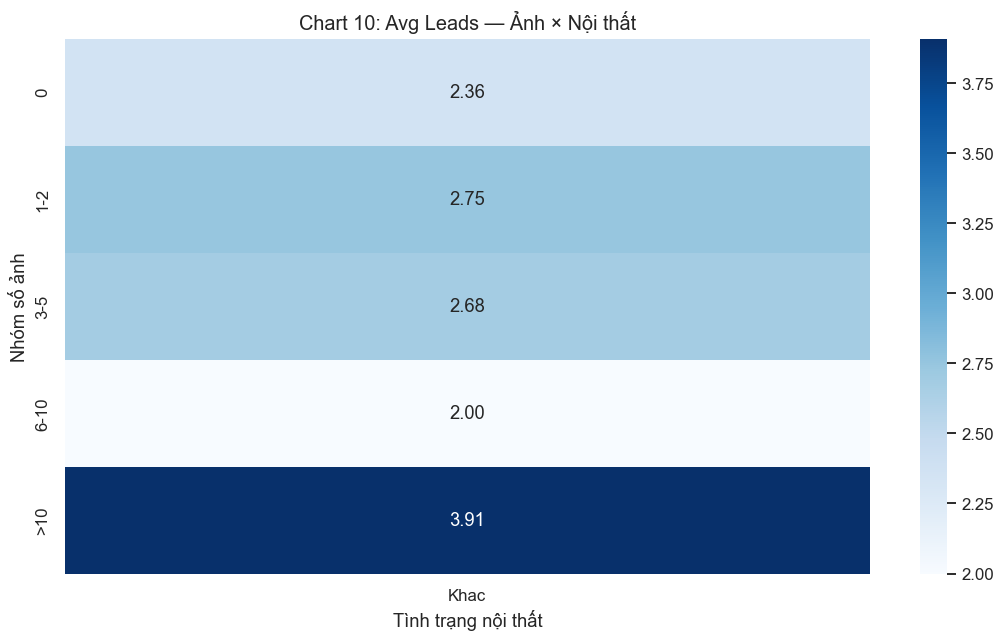

In [61]:
# Chart 10: img_bin x furnishing → avg leads heatmap
hm10 = df_item.groupby(['img_bin','furnishing_clean'], observed=True)['n_leads'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10,6))
sns.heatmap(hm10, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Chart 10: Avg Leads — Ảnh × Nội thất', fontsize=13)
ax.set_xlabel('Tình trạng nội thất'); ax.set_ylabel('Nhóm số ảnh')
plt.tight_layout(); plt.show()


**Chart 10 — Ảnh × Nội thất và Leads**: Ô tối nhất = leads cao nhất. Nhiều ảnh và nội thất đầy đủ cộng hưởng nhau — chỉ có một trong hai vẫn chưa đủ để tối đa hóa leads.

---
# Zone 4 — Seller Intelligence Nâng cao (4 charts)

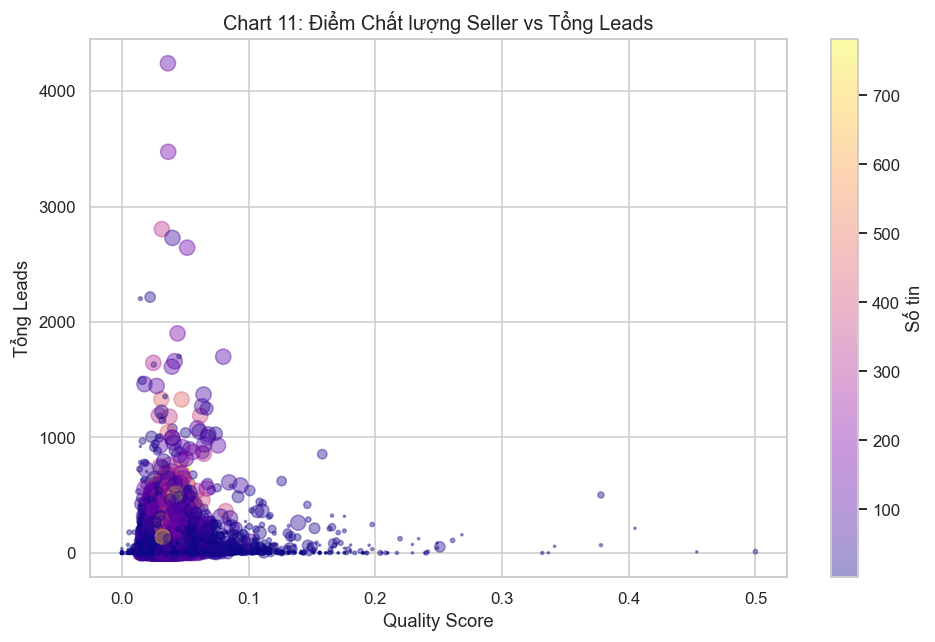

In [62]:
# Chart 11: Seller quality score scatter
seller_q = df_item.groupby('seller_id', observed=True).agg(
    avg_images =('images_count','mean'),
    n_listings =('item_id','count'),
    total_leads=('n_leads','sum'),
    furn_rate  =('furnishing_clean', lambda x: (x=='Đầy đủ').mean())
).reset_index()
seller_q['quality_score'] = (seller_q['avg_images']/seller_q['avg_images'].max().clip(1) +
                              seller_q['furn_rate']) / 2
fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(seller_q['quality_score'], seller_q['total_leads'],
                alpha=0.4, s=seller_q['n_listings'].clip(1,50)*2,
                c=seller_q['n_listings'], cmap='plasma')
plt.colorbar(sc, ax=ax, label='Số tin')
ax.set_title('Chart 11: Điểm Chất lượng Seller vs Tổng Leads', fontsize=13)
ax.set_xlabel('Quality Score'); ax.set_ylabel('Tổng Leads')
plt.tight_layout(); plt.show()


**Chart 11 — Seller Quality Score**: Xu hướng dốc lên phải → seller đầu tư vào chất lượng listing thật sự nhận được nhiều leads hơn. Kích thước điểm thể hiện số tin đăng mỗi seller.

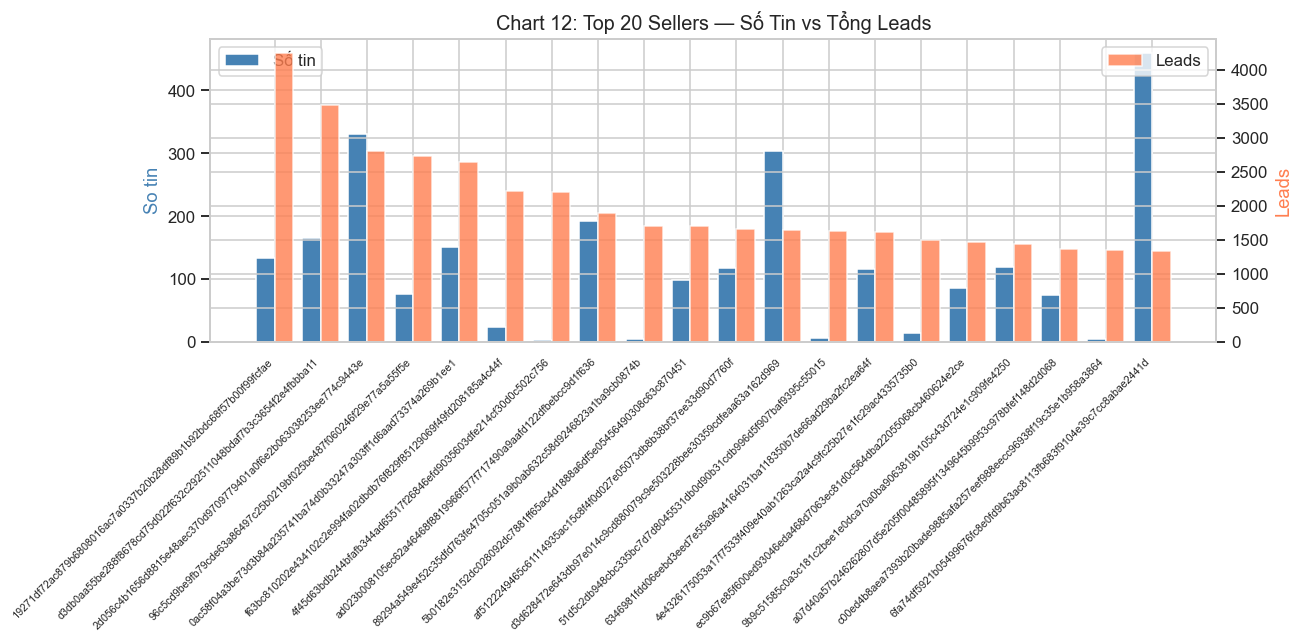

In [63]:
# Chart 12: Top 20 sellers: n_listings vs total_leads
top20 = seller_q.nlargest(20, 'total_leads')
fig, ax = plt.subplots(figsize=(12,6))
x12 = range(len(top20)); w = 0.4
ax.bar([i-w/2 for i in x12], top20['n_listings'], width=w, label='Số tin', color='steelblue')
ax2b = ax.twinx()
ax2b.bar([i+w/2 for i in x12], top20['total_leads'], width=w, label='Leads', color='coral', alpha=0.8)
ax.set_xticks(x12); ax.set_xticklabels(top20['seller_id'].astype(str), rotation=45, ha='right', fontsize=7)
ax.set_ylabel('So tin', color='steelblue'); ax2b.set_ylabel('Leads', color='coral')
ax.set_title('Chart 12: Top 20 Sellers — Số Tin vs Tổng Leads', fontsize=13)
ax.legend(loc='upper left'); ax2b.legend(loc='upper right')
plt.tight_layout(); plt.show()


**Chart 12 — Top 20 Sellers**: Seller ít tin nhưng leads cao → mỗi tin chất lượng tốt. Seller nhiều tin nhưng leads thấp → đăng nhiều không hiệu quả, có thể là spam hoặc thiếu tối ưu.

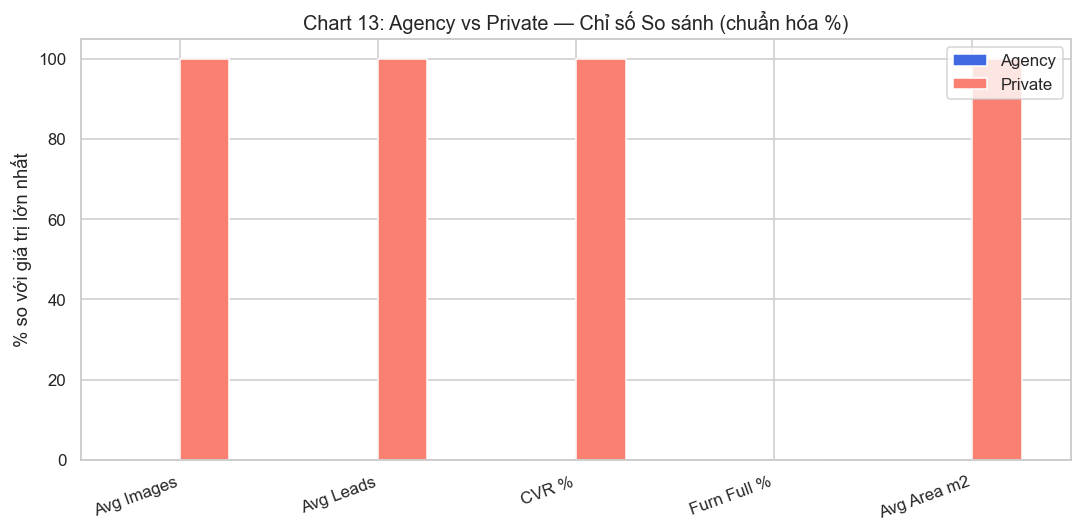


Giá trị tuyet doi:
             Agency  Private
Avg Images      NaN     6.93
Avg Leads       NaN     2.54
CVR %           NaN    16.99
Furn Full %     NaN     0.00
Avg Area m2     NaN    91.51


In [64]:
# Chart 13: Agency vs Private comparison
ag = df_item[df_item['seller_type']=='agency']
pr = df_item[df_item['seller_type']!='agency']
comp13 = pd.DataFrame({
    'Agency' : [ag['images_count'].mean(), ag['n_leads'].mean(), ag['has_lead'].mean()*100,
                (ag['furnishing_clean']=='Đầy đủ').mean()*100, ag['area_sqm'].mean()],
    'Private': [pr['images_count'].mean(), pr['n_leads'].mean(), pr['has_lead'].mean()*100,
                (pr['furnishing_clean']=='Đầy đủ').mean()*100, pr['area_sqm'].mean()]
}, index=['Avg Images','Avg Leads','CVR %','Furn Full %','Avg Area m2'])
comp13_norm = comp13.div(comp13.max(axis=1).clip(lower=0.001), axis=0)*100
fig, ax = plt.subplots(figsize=(10,5))
comp13_norm.plot(kind='bar', ax=ax, color=['royalblue','salmon'])
ax.set_title('Chart 13: Agency vs Private — Chỉ số So sánh (chuẩn hóa %)', fontsize=13)
ax.set_ylabel('% so với giá trị lớn nhất'); ax.set_xticklabels(comp13_norm.index, rotation=20, ha='right')
ax.legend(); plt.tight_layout(); plt.show()
print("\nGiá trị tuyet doi:"); print(comp13.round(2))


**Chart 13 — Agency vs Private**: Agency dẫn đầu về số ảnh và nội thất đầy đủ do quy trình chuyên nghiệp. Private seller đôi khi CVR cao hơn vì là chủ nhà thực sự, phản hồi nhanh và linh hoạt hơn.

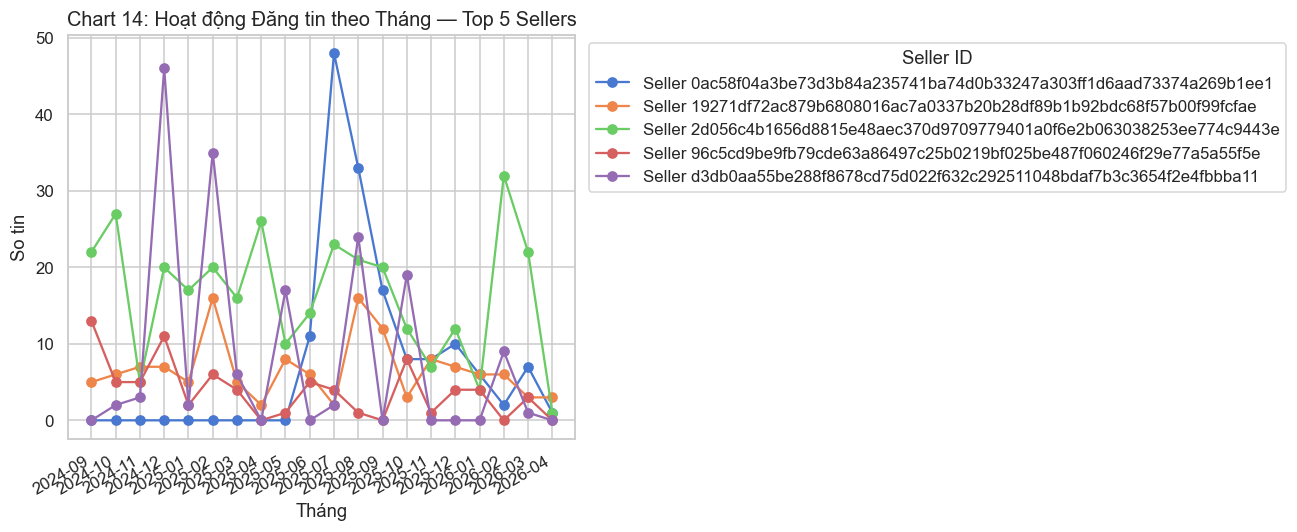

In [65]:
# Chart 14: Monthly activity top 5 sellers
top5_s = seller_q.nlargest(5,'total_leads')['seller_id'].tolist()
df14 = df_item[df_item['seller_id'].isin(top5_s)][['seller_id','posted_month']].dropna()
act14 = df14.groupby(['posted_month','seller_id']).size().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(12,5))
for col in act14.columns:
    ax.plot(act14.index, act14[col], marker='o', label=f'Seller {col}')
ax.set_title('Chart 14: Hoạt động Đăng tin theo Tháng — Top 5 Sellers', fontsize=13)
ax.set_xlabel('Tháng'); ax.set_ylabel('So tin')
ax.legend(title='Seller ID', bbox_to_anchor=(1.01,1))
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()


**Chart 14 — Hoạt động theo Tháng**: Seller tang dot bien = mo rong danh muc. Seller giam = đã cho thuê hết phòng. Tín hiệu mùa vụ.

---
# Zone 5 — Địa lý Nâng cao (4 charts)

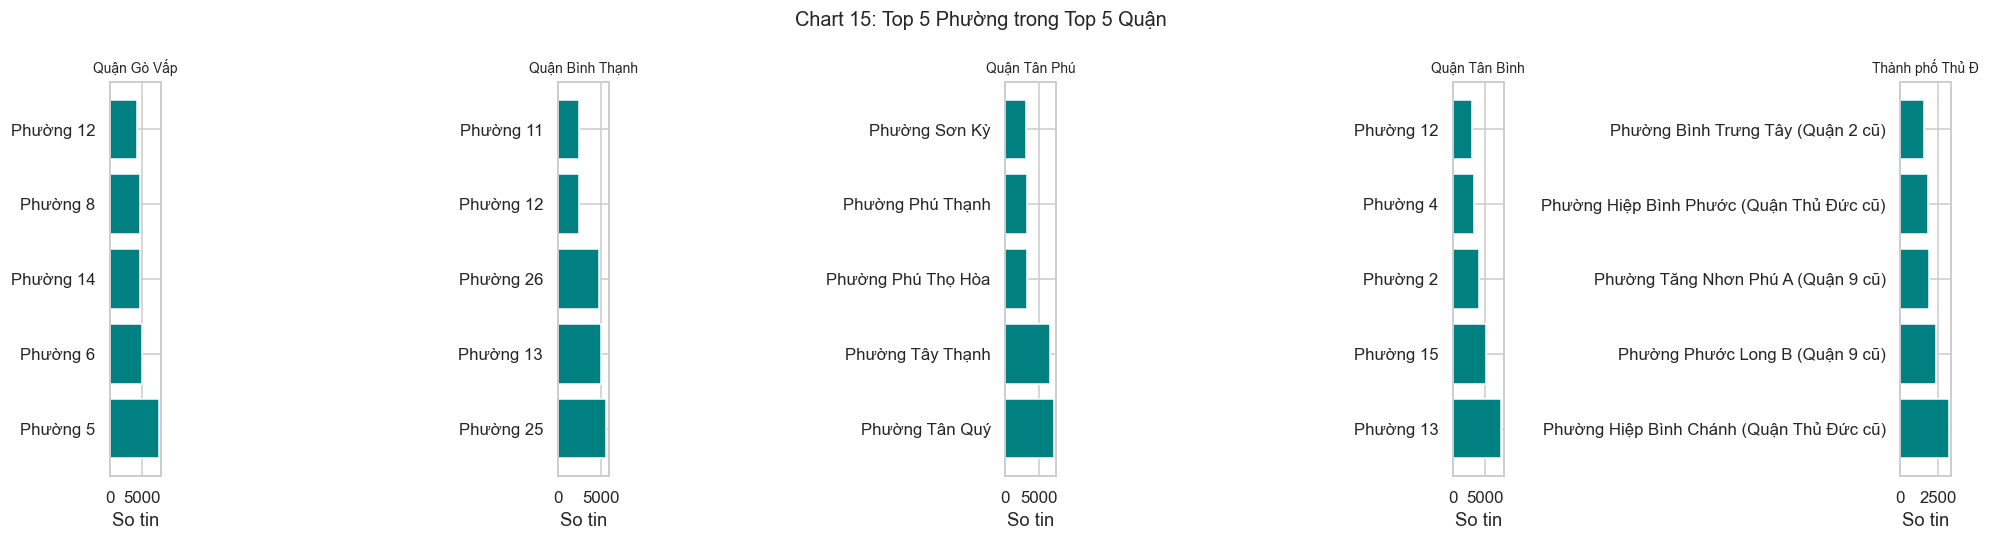

In [66]:
# Chart 15: Ward supply trong top 5 districts
top5_dist = df_item['district_name'].value_counts().head(5).index.tolist() if 'district_name' in df_item.columns else []
if top5_dist and 'ward_name' in df_item.columns:
    ws = df_item[df_item['district_name'].isin(top5_dist)].groupby(
        ['district_name','ward_name'])['item_id'].count().reset_index()
    fig, axes = plt.subplots(1,5,figsize=(18,5),sharey=False)
    for ax, dist in zip(axes, top5_dist):
        sub = ws[ws['district_name']==dist].nlargest(5,'item_id')
        ax.barh(sub['ward_name'], sub['item_id'], color='teal')
        ax.set_title(str(dist)[:15], fontsize=9); ax.set_xlabel('So tin')
    fig.suptitle('Chart 15: Top 5 Phường trong Top 5 Quận', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("Không có cột district_name / ward_name")


**Chart 15 — Cung theo Phường trong Top Quận**: Phuong nao nhieu tin nhat? Neu 1 phuong chiem >50% cua quan → nguồn cung rất tập trung.

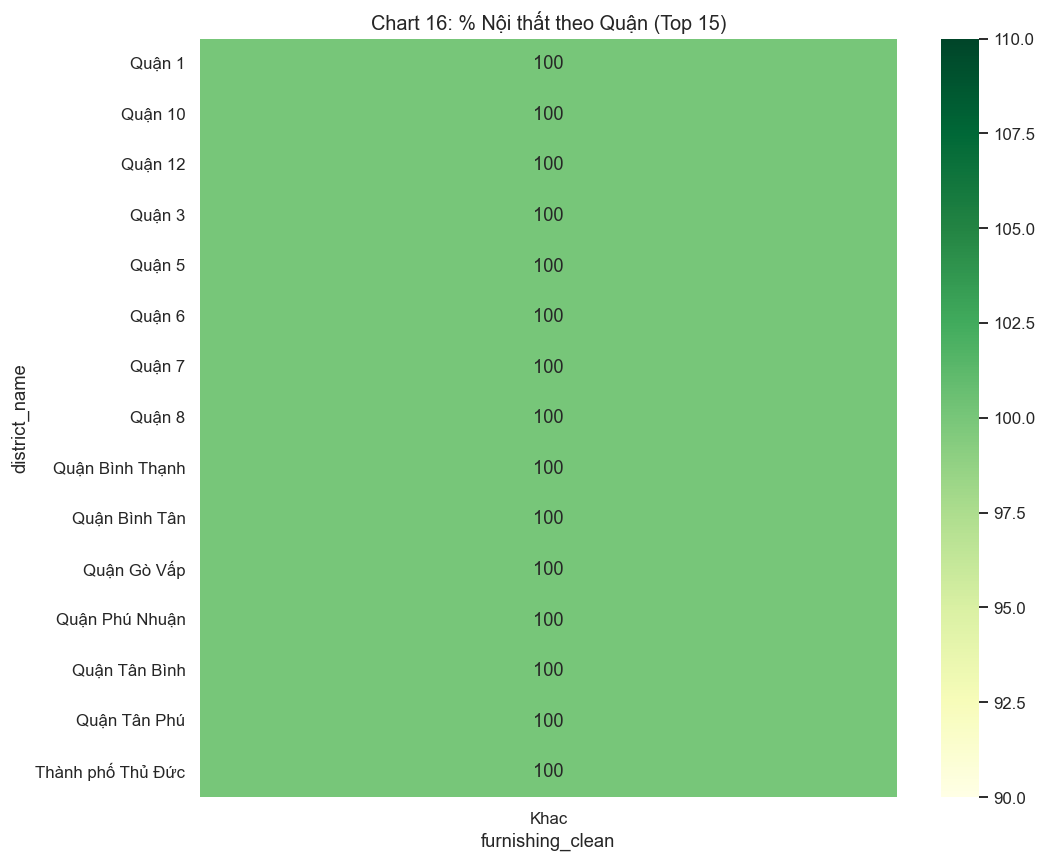

In [67]:
# Chart 16: District x furnishing heatmap
top15_dist = df_item['district_name'].value_counts().head(15).index.tolist() if 'district_name' in df_item.columns else []
if top15_dist:
    df16 = df_item[df_item['district_name'].isin(top15_dist)]
    hm16 = df16.groupby(['district_name','furnishing_clean'], observed=True)['item_id'].count().unstack(fill_value=0)
    hm16_pct = hm16.div(hm16.sum(axis=1), axis=0)*100
    fig, ax = plt.subplots(figsize=(10,8))
    sns.heatmap(hm16_pct, annot=True, fmt='.0f', cmap='YlGn', ax=ax)
    ax.set_title('Chart 16: % Nội thất theo Quận (Top 15)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 16 — Nội thất theo Quận**: Quận nhiều nội thất đầy đủ = thị trường cao cấp. Quận nhiều không nội thất = thị trường sinh vien/cong nhan.

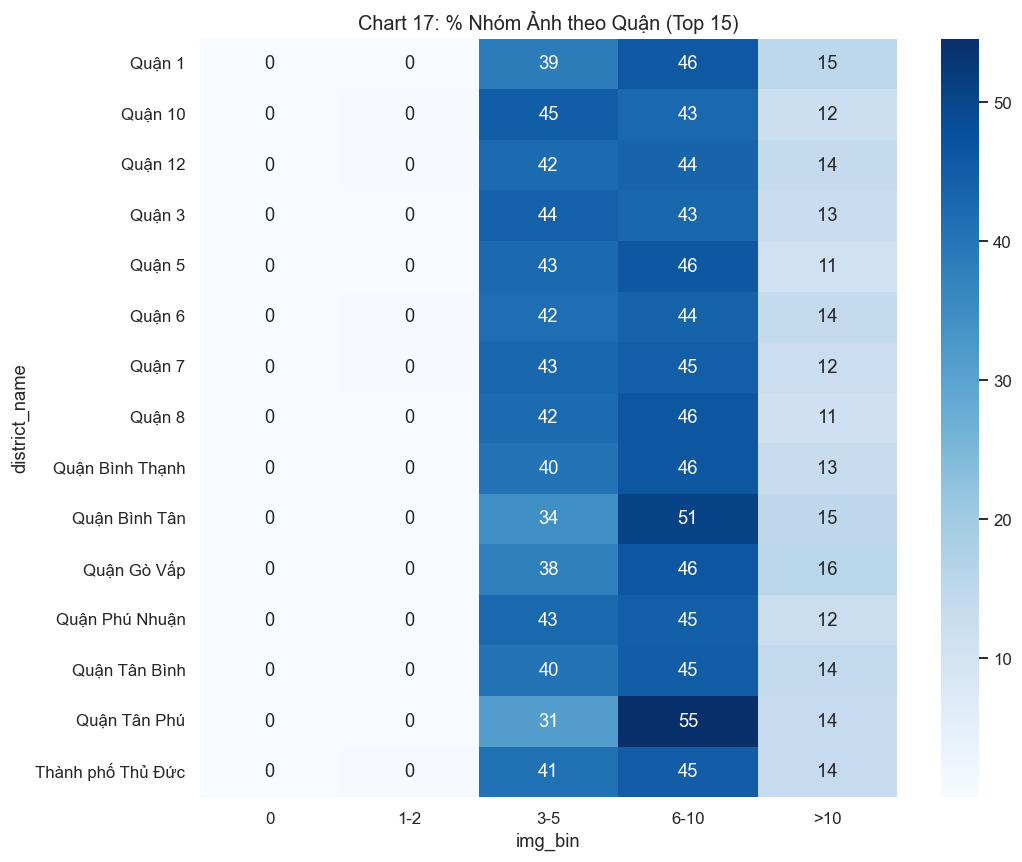

In [68]:
# Chart 17: District x img_bin heatmap
if top15_dist:
    hm17 = df_item[df_item['district_name'].isin(top15_dist)].groupby(
        ['district_name','img_bin'], observed=True)['item_id'].count().unstack(fill_value=0)
    hm17_pct = hm17.div(hm17.sum(axis=1), axis=0)*100
    fig, ax = plt.subplots(figsize=(10,8))
    sns.heatmap(hm17_pct, annot=True, fmt='.0f', cmap='Blues', ax=ax)
    ax.set_title('Chart 17: % Nhóm Ảnh theo Quận (Top 15)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 17 — Số ảnh theo Quận**: Quận nhiều listing 0 ảnh → vấn đề chất lượng cục bộ. CVR van cao → nhu cau manh, seller chưa khai thác hết tiềm năng tiem nang.

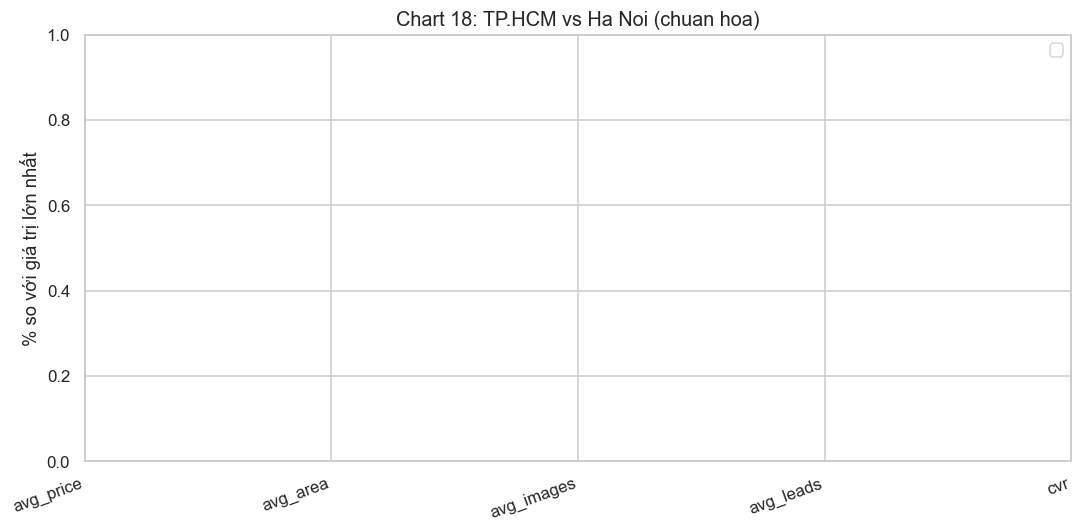


Giá trị tuyet doi:
Empty DataFrame
Columns: []
Index: [avg_price, avg_area, avg_images, avg_leads, cvr]


In [69]:
# Chart 18: HCM vs Ha Noi
if 'city_name' in df_item.columns:
    def city_flag(v):
        if pd.isna(v): return 'Khac'
        v = str(v).lower()
        if any(k in v for k in ['chi minh','hcm','sai gon','tp.hcm']): return 'TP.HCM'
        if any(k in v for k in ['ha noi','hanoi']): return 'Ha Noi'
        return 'Khac'
    df_item['city_group'] = df_item['city_name'].apply(city_flag)
    cg = df_item[df_item['city_group'].isin(['TP.HCM','Ha Noi'])].groupby('city_group').agg(
        avg_price  =('price_value','mean'),
        avg_area   =('area_sqm','mean'),
        avg_images =('images_count','mean'),
        avg_leads  =('n_leads','mean'),
        cvr        =('has_lead','mean')
    ).T
    city_norm = cg.div(cg.max(axis=1).clip(0.001), axis=0)
    fig, ax = plt.subplots(figsize=(10,5))
    x18 = range(len(city_norm)); w18=0.35
    if 'TP.HCM' in city_norm: ax.bar([i-w18/2 for i in x18], city_norm['TP.HCM'], w18, label='TP.HCM', color='royalblue')
    if 'Ha Noi' in city_norm: ax.bar([i+w18/2 for i in x18], city_norm['Ha Noi'], w18, label='Ha Noi', color='tomato')
    ax.set_xticks(x18); ax.set_xticklabels(city_norm.index, rotation=20, ha='right')
    ax.set_title('Chart 18: TP.HCM vs Ha Noi (chuan hoa)', fontsize=13)
    ax.set_ylabel('% so với giá trị lớn nhất'); ax.legend(); plt.tight_layout(); plt.show()
    print("\nGiá trị tuyet doi:"); print(cg.round(3))
else:
    print("Không có cột city_name")


**Chart 18 — TP.HCM vs Hà Nội**: TP.HCM thường giá cao hơn, và diện tích nhỏ hơn do mật độ đô thị cao. Hà Nội có xu hướng diện tích lớn hơn. CVR phản ánh mức độ cạnh tranh khac nhau.

---
# Zone 6 — Hành vi User Nâng cao (6 charts — DuckDB only)

Cột đã biết: `is_login`, `event_type`, `query`, `surface`, `position`, `device`, `dwell_time_sec`, `is_contact`

In [70]:
# Xac nhan schema ev_1050
schema6 = con.execute("DESCRIBE ev_1050").df()
print(schema6[['column_name','column_type']].to_string())


       column_name column_type
0         is_login     VARCHAR
1          user_id     VARCHAR
2       session_id     VARCHAR
3         event_id     VARCHAR
4          item_id     VARCHAR
5        city_name     VARCHAR
6         category      BIGINT
7       event_type     VARCHAR
8            query     VARCHAR
9         event_ts   TIMESTAMP
10         surface     VARCHAR
11        position      BIGINT
12          device     VARCHAR
13  dwell_time_sec      BIGINT
14      is_contact      BIGINT
15            date        DATE


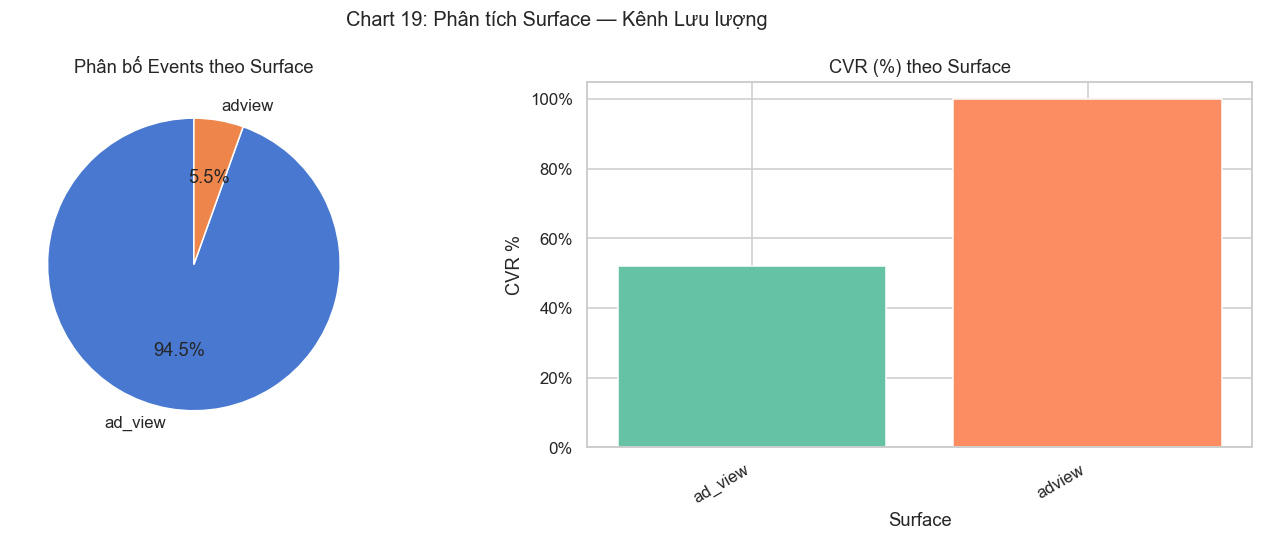

surface    total   contacts        cvr
ad_view 38576993 20087163.0  52.070318
 adview  2230184  2230184.0 100.000000


In [71]:
# Chart 19: Surface breakdown — pie + CVR
df19 = con.execute("""
SELECT surface,
       COUNT(*) AS total,
       SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
GROUP BY surface ORDER BY total DESC LIMIT 10
""").df()
df19['cvr'] = df19['contacts'] / df19['total'] * 100

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(13,5))
ax1.pie(df19['total'], labels=df19['surface'], autopct='%1.1f%%', startangle=90)
ax1.set_title('Phân bố Events theo Surface')
ax2.bar(df19['surface'].astype(str), df19['cvr'], color=sns.color_palette('Set2',len(df19)))
ax2.set_title('CVR (%) theo Surface')
ax2.set_xlabel('Surface'); ax2.set_ylabel('CVR %')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30, ha='right')
fig.suptitle('Chart 19: Phân tích Surface — Kênh Lưu lượng', fontsize=13)
plt.tight_layout(); plt.show()
print(df19[['surface','total','contacts','cvr']].to_string(index=False))


**Chart 19 — Surface Analysis**: Surface cho biết người dùng tìm thấy listing qua đâu. Browse thuong intent cao hon recommendation.

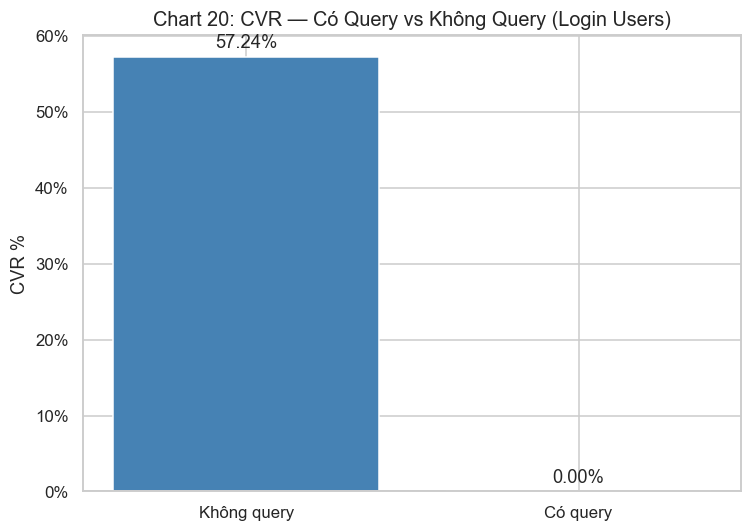

            qg     total    contacts    cvr_pct
0  Không query  38985720  22317347.0  57.244927
1     Có query   1821457         0.0   0.000000


In [72]:
# Chart 20: has_query vs no_query → CVR
df20 = con.execute("""
SELECT
    CASE WHEN query IS NOT NULL AND query != '' THEN 'Có query' ELSE 'Không query' END AS qg,
    COUNT(*) AS total,
    SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
GROUP BY 1
""").df()
df20['cvr_pct'] = df20['contacts'] / df20['total'] * 100
fig, ax = plt.subplots(figsize=(7,5))
bars20 = ax.bar(df20['qg'], df20['cvr_pct'], color=['steelblue','coral'])
ax.bar_label(bars20, fmt='%.2f%%', padding=3)
ax.set_title('Chart 20: CVR — Có Query vs Không Query (Login Users)', fontsize=13)
ax.set_ylabel('CVR %'); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()
print(df20)


**Chart 20 — Query vs No Query**: Người dùng tìm kiếm có từ khóa cụ thể thường có ý định cao hơn (intent-driven), dẫn đến CVR cao hơn. Nếu CVR không có query lại cao → hệ thống gợi ý đang hoạt động tốt.

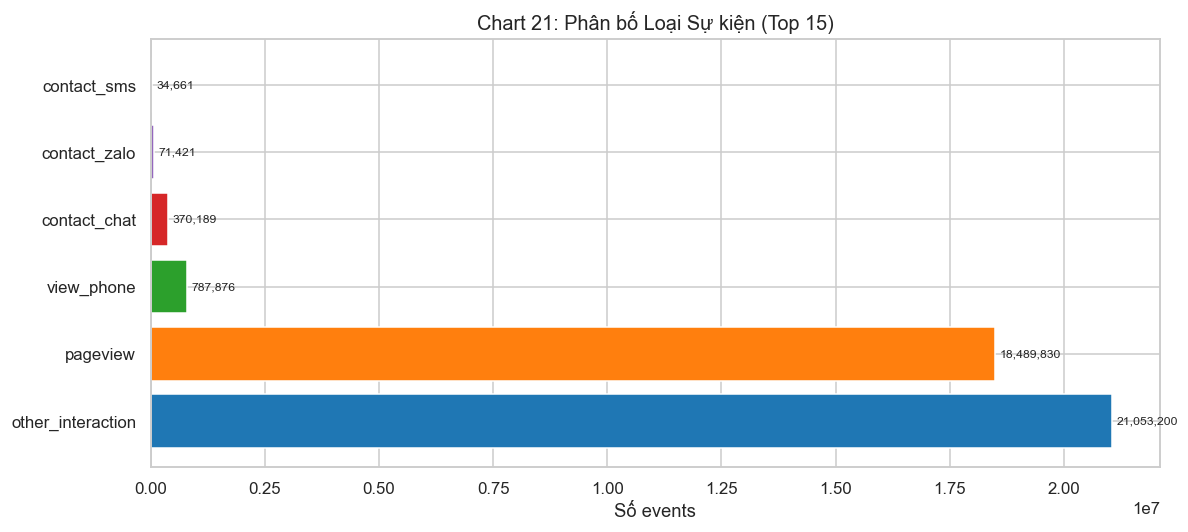

       event_type      cnt
other_interaction 21053200
         pageview 18489830
       view_phone   787876
     contact_chat   370189
     contact_zalo    71421
      contact_sms    34661


In [73]:
# Chart 21: Event type distribution
df21 = con.execute("""
SELECT event_type, COUNT(*) AS cnt
FROM ev_1050
GROUP BY event_type ORDER BY cnt DESC LIMIT 15
""").df()
fig, ax = plt.subplots(figsize=(11,5))
bars21 = ax.barh(df21['event_type'], df21['cnt'], color=sns.color_palette('tab10',len(df21)))
ax.set_title('Chart 21: Phân bố Loại Sự kiện (Top 15)', fontsize=13)
ax.set_xlabel('Số events')
ax.bar_label(bars21, labels=[f'{v:,.0f}' for v in df21['cnt']], padding=3, fontsize=8)
plt.tight_layout(); plt.show()
print(df21.to_string(index=False))


**Chart 21 — Phân bố Event**: Tỷ lệ contact events / total events = CVR tổng thể. Event 'is_contact=True' la tín hiệu chuyển đổi mạnh nhất.

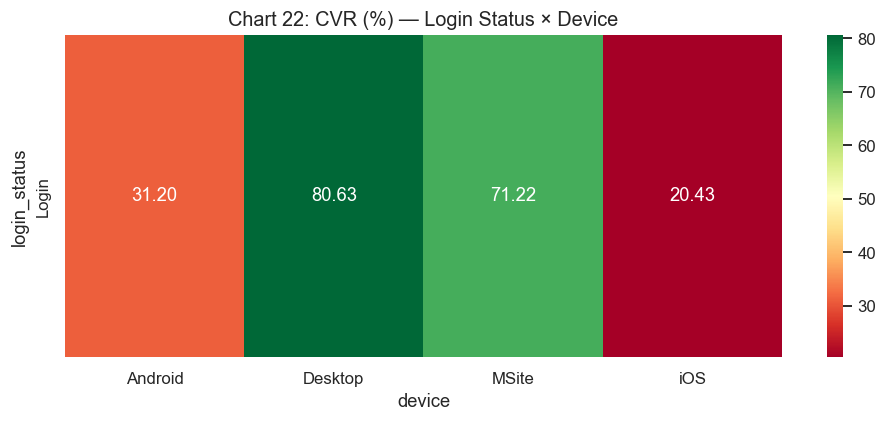

device        Android  Desktop  MSite    iOS
login_status                                
Login            31.2    80.63  71.22  20.43


In [74]:
# Chart 22: Login x Device → CVR heatmap
df22 = con.execute("""
SELECT
    CASE WHEN CAST(is_login AS VARCHAR) NOT IN ('false','0','False','') AND is_login IS NOT NULL
         THEN 'Login' ELSE 'Anonymous' END AS login_status,
    device,
    COUNT(*) AS total,
    SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
WHERE device IS NOT NULL
GROUP BY 1,2
""").df()
df22['cvr'] = df22['contacts'] / df22['total'] * 100
piv22 = df22.pivot_table(index='login_status', columns='device', values='cvr', aggfunc='mean').fillna(0)
fig, ax = plt.subplots(figsize=(9,4))
sns.heatmap(piv22, annot=True, fmt='.2f', cmap='RdYlGn', ax=ax)
ax.set_title('Chart 22: CVR (%) — Login Status × Device', fontsize=13)
plt.tight_layout(); plt.show()
print(piv22.round(2))


**Chart 22 — Hành vi theo Device**: Nguoi dung da login thuong CVR cao hon (co tai khoan san de lien he). Ket qua giup toi uu UX theo platform.

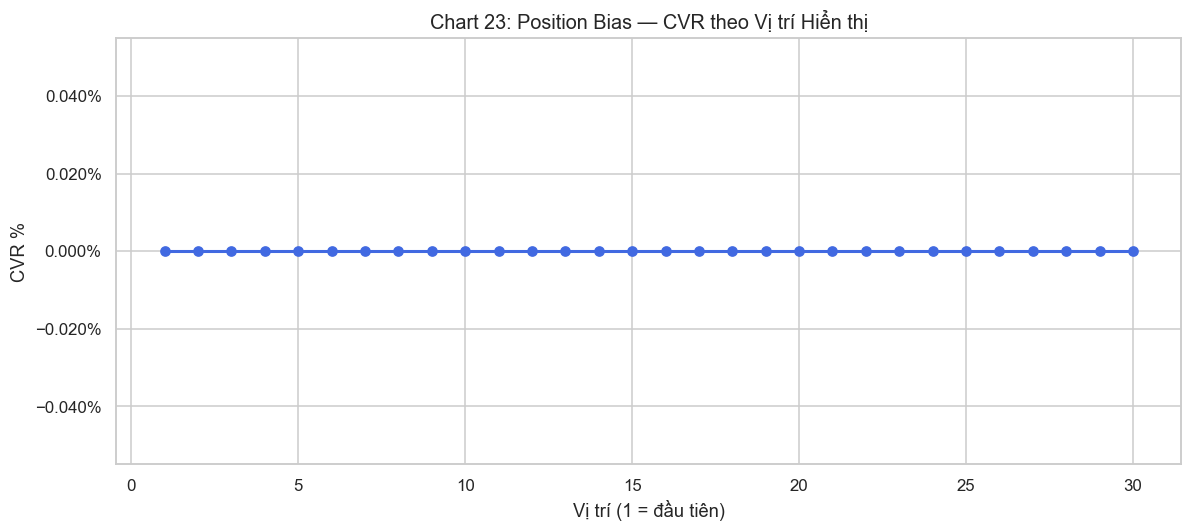

In [75]:
# Chart 23: Position bias curve (pos 1-30)
df23 = con.execute("""
SELECT
    CAST(position AS INTEGER) AS pos,
    COUNT(*) AS total,
    SUM(CAST(is_contact AS INTEGER)) AS contacts
FROM ev_1050
WHERE position IS NOT NULL AND CAST(position AS INTEGER) BETWEEN 1 AND 30
GROUP BY pos ORDER BY pos
""").df()
df23['cvr'] = df23['contacts'] / df23['total'] * 100
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(df23['pos'], df23['cvr'], 'o-', color='royalblue', linewidth=2)
ax.fill_between(df23['pos'], df23['cvr'], alpha=0.2)
ax.set_title('Chart 23: Position Bias — CVR theo Vị trí Hiển thị', fontsize=13)
ax.set_xlabel('Vị trí (1 = đầu tiên)'); ax.set_ylabel('CVR %')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()


**Chart 23 — Position Bias**: CVR giam dan theo vi tri — listing vi tri 1-3 nhận được nhiều contact nhất. Bằng chứng về giá trị SEO/ranking.

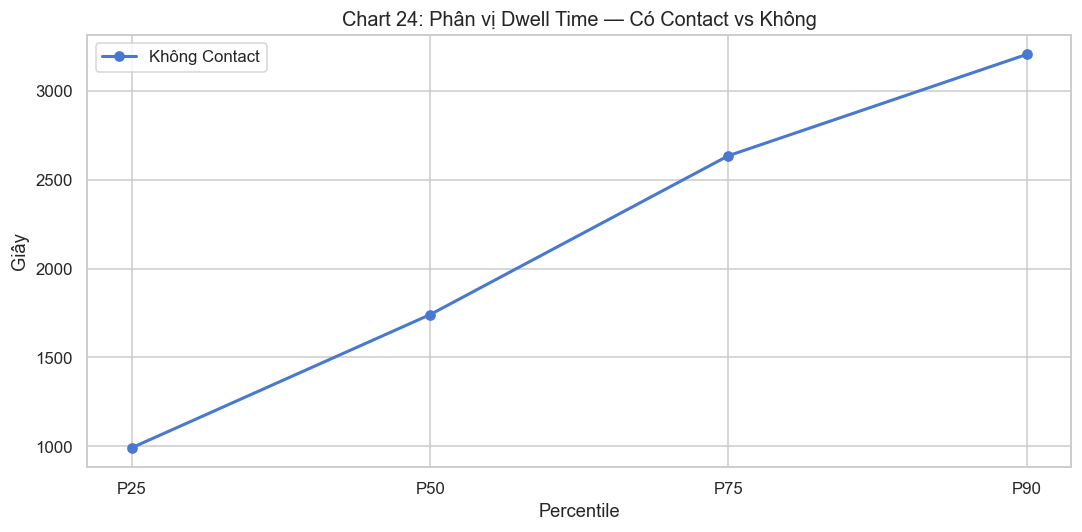

18374

In [76]:
# Chart 24: Dwell time percentile — contact vs no-contact
df24 = con.execute("""
SELECT
    dwell_time_sec,
    CASE WHEN is_contact THEN 'Có Contact' ELSE 'Không Contact' END AS contact_flag
FROM ev_1050
WHERE dwell_time_sec IS NOT NULL AND dwell_time_sec > 0 AND dwell_time_sec < 3600
LIMIT 500000
""").df()
fig, ax = plt.subplots(figsize=(10,5))
for flag, grp in df24.groupby('contact_flag'):
    pcts = np.percentile(grp['dwell_time_sec'].dropna(), [25,50,75,90])
    ax.plot(['P25','P50','P75','P90'], pcts, marker='o', label=flag, linewidth=2)
ax.set_title('Chart 24: Phân vị Dwell Time — Có Contact vs Không', fontsize=13)
ax.set_xlabel('Percentile'); ax.set_ylabel('Giây')
ax.legend(); plt.tight_layout(); plt.show()
del df24; gc.collect()


**Chart 24 — Dwell Time**: Người dùng xem trang lâu hơn có xu hướng liên hệ cao hơn. Dwell time là tín hiệu tốt de predict intent.

---
# Zone 7 — Vòng đời Listing Nâng cao (4 charts)

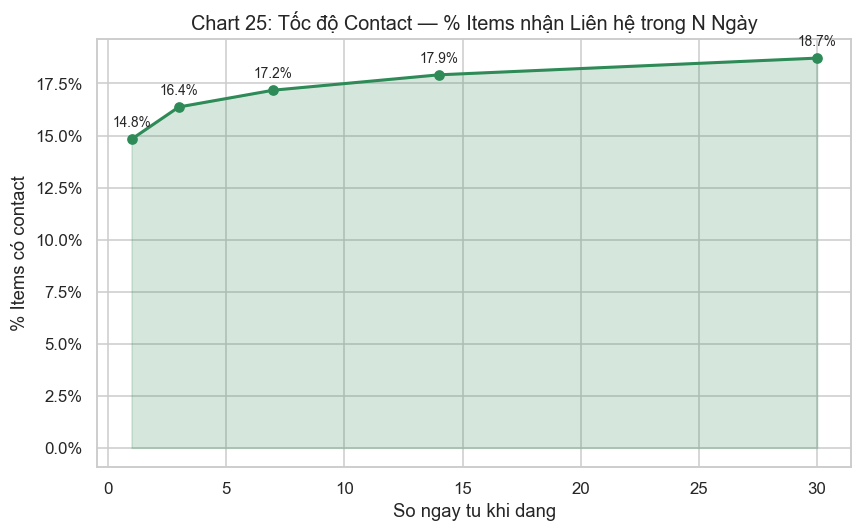

In [77]:
# Chart 25: Contact velocity
df_item['first_contact'] = pd.to_datetime(df_item['first_contact'], errors='coerce')
df_item['days_to_first'] = (df_item['first_contact'] - df_item['posted_date']).dt.days

thresholds = [1,3,7,14,30]
vel = [(df_item['days_to_first'] <= t).sum()/len(df_item)*100 for t in thresholds]
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, vel, 'o-', color='seagreen', linewidth=2)
ax.fill_between(thresholds, vel, alpha=0.2, color='seagreen')
for t,p in zip(thresholds,vel):
    ax.annotate(f'{p:.1f}%', (t,p), textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
ax.set_title('Chart 25: Tốc độ Contact — % Items nhận Liên hệ trong N Ngày', fontsize=13)
ax.set_xlabel('So ngay tu khi dang'); ax.set_ylabel('% Items có contact')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()


**Chart 25 — Contact Velocity**: Đường dốc lên nhanh = thị trường quyết định nhanh. Listing không contact sau 14 ngày thìường có vấn đề chất lượng hoặc giá.

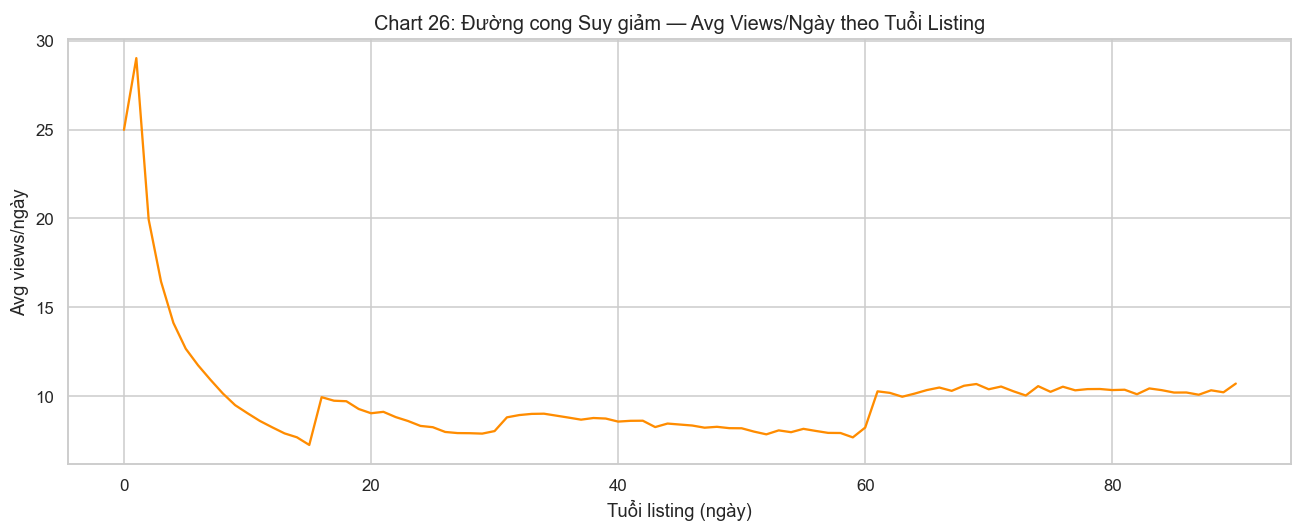

In [78]:
# Chart 26: Views decay theo listing_age_days (da co san trong snapshot)
df26 = con.execute("""
SELECT listing_age_days AS age, AVG(views_24h) AS avg_views
FROM snap_raw
WHERE views_24h IS NOT NULL AND listing_age_days BETWEEN 0 AND 90
GROUP BY listing_age_days ORDER BY listing_age_days
""").df()
if len(df26):
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(df26['age'], df26['avg_views'], color='darkorange', linewidth=1.5)
    ax.set_title('Chart 26: Đường cong Suy giảm — Avg Views/Ngày theo Tuổi Listing', fontsize=13)
    ax.set_xlabel('Tuổi listing (ngày)'); ax.set_ylabel('Avg views/ngày')
    plt.tight_layout(); plt.show()
else:
    print("Không đủ dữ liệu cho Chart này")


**Chart 26 — Views Decay**: Views giam dan theo thoi gian. Nên re-bump listing sau 7 ngày de duy tri visibility.

Dead listings: 300,112 / 361,556 = 83.0%


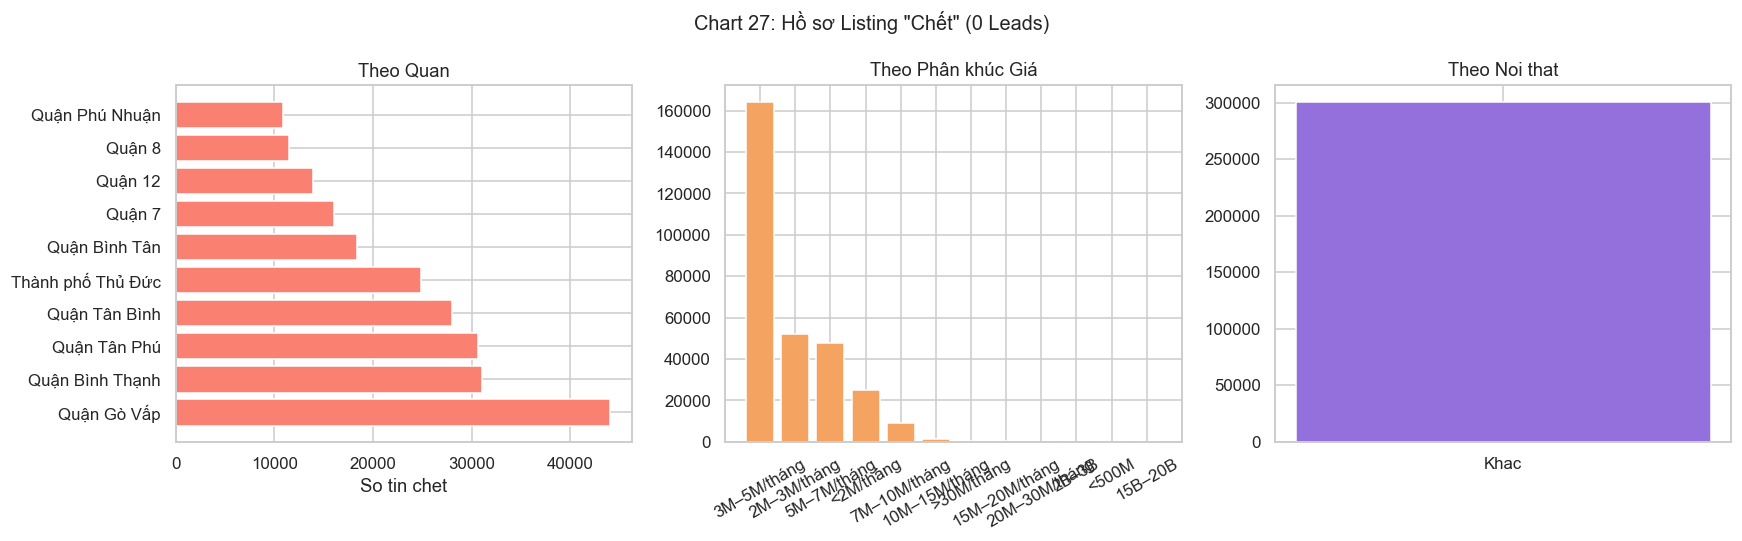

In [79]:
# Chart 27: Dead listings profile
dead = df_item[df_item['n_leads'] == 0].copy()
print(f"Dead listings: {len(dead):,} / {len(df_item):,} = {len(dead)/len(df_item)*100:.1f}%")
fig, axes = plt.subplots(1,3,figsize=(16,5))
if 'district_name' in dead.columns:
    dd = dead['district_name'].value_counts().head(10)
    axes[0].barh(dd.index, dd.values, color='salmon')
    axes[0].set_title('Theo Quan'); axes[0].set_xlabel('So tin chet')
if 'price_bucket' in dead.columns:
    dp = dead['price_bucket'].value_counts()
    axes[1].bar(dp.index.astype(str), dp.values, color='sandybrown')
    axes[1].set_title('Theo Phân khúc Giá'); axes[1].tick_params(axis='x', rotation=30)
df27_furn = dead['furnishing_clean'].value_counts()
axes[2].bar(df27_furn.index, df27_furn.values, color='mediumpurple')
axes[2].set_title('Theo Noi that')
fig.suptitle('Chart 27: Hồ sơ Listing "Chết" (0 Leads)', fontsize=13)
plt.tight_layout(); plt.show()


**Chart 27 — Dead Listings**: Listing 0 contact tập trung ở quận nào / giá nào / nội thất nào → xác định vấn đề cục bộ.

Sellers nghi ngờ relist: 13,172


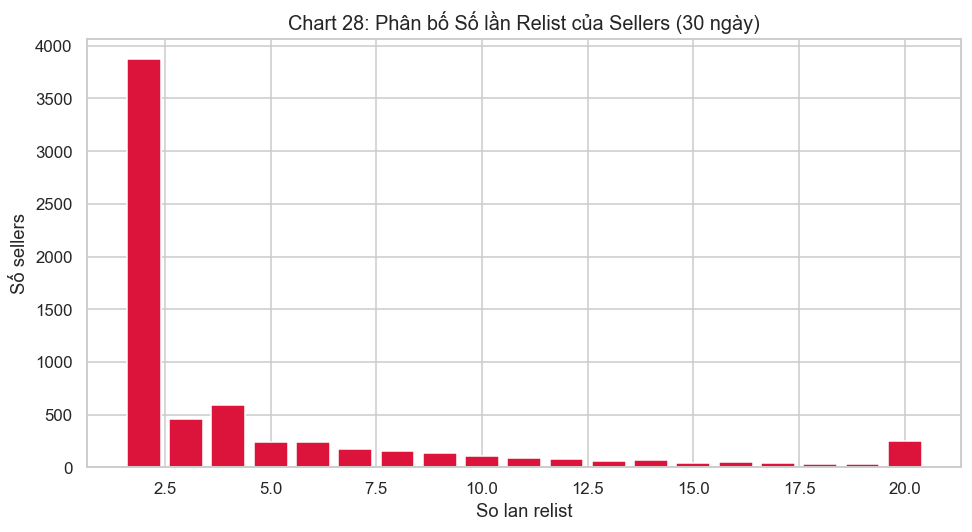

In [80]:
# Chart 28: Relisting detection
relist_keys = [c for c in ['seller_id','ward_name','price_bucket'] if c in df_item.columns]
if len(relist_keys) >= 2:
    rg = df_item.groupby(relist_keys, observed=True).agg(
        n_list=('item_id','count'),
        date_range=('posted_date', lambda x: (x.max()-x.min()).days if len(x)>1 else 0)
    ).reset_index()
    rc = rg[(rg['n_list']>1) & (rg['date_range']<=30)]
    relist_per_seller = rc.groupby('seller_id', observed=True)['n_list'].sum()
    fig, ax = plt.subplots(figsize=(9,5))
    rh = relist_per_seller.clip(0,20).value_counts().sort_index()
    ax.bar(rh.index, rh.values, color='crimson')
    ax.set_title('Chart 28: Phân bố Số lần Relist của Sellers (30 ngày)', fontsize=13)
    ax.set_xlabel('So lan relist'); ax.set_ylabel('Số sellers')
    print(f"Sellers nghi ngờ relist: {len(rc):,}")
    plt.tight_layout(); plt.show()
else:
    print("Khong du cot de detect relist")


**Chart 28 — Relisting Detection**: Sellers relist >10 lần trong 30 ngay → co the spam (dang/xoa/dang lai de luon o dau). Van de can kiem soat.

---
# Zone 8 — Phân tích Đa chiều (4 charts)

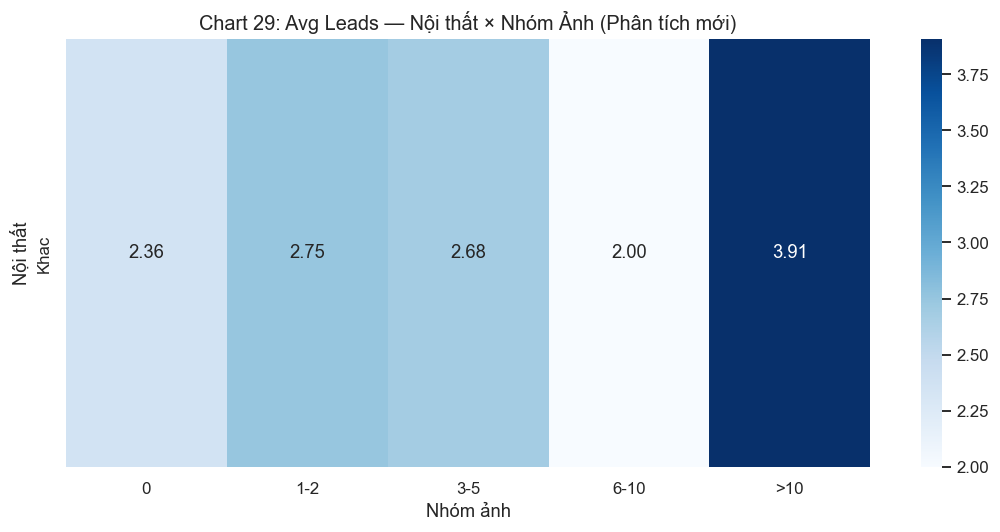

In [81]:
# Chart 29: Furnishing x img_bin → avg leads
hm29 = df_item.groupby(['furnishing_clean','img_bin'], observed=True)['n_leads'].mean().unstack(fill_value=0)
fig, ax = plt.subplots(figsize=(10,5))
sns.heatmap(hm29, annot=True, fmt='.2f', cmap='Blues', ax=ax)
ax.set_title('Chart 29: Avg Leads — Nội thất × Nhóm Ảnh (Phân tích mới)', fontsize=13)
ax.set_xlabel('Nhóm ảnh'); ax.set_ylabel('Nội thất')
plt.tight_layout(); plt.show()


**Chart 29** (moi — chưa có trong 2 notebook cũ): Ket hop noi that day du + nhieu anh → leads cao nhat. Xem xet song song voi gia de co khuyen nghi toan dien.

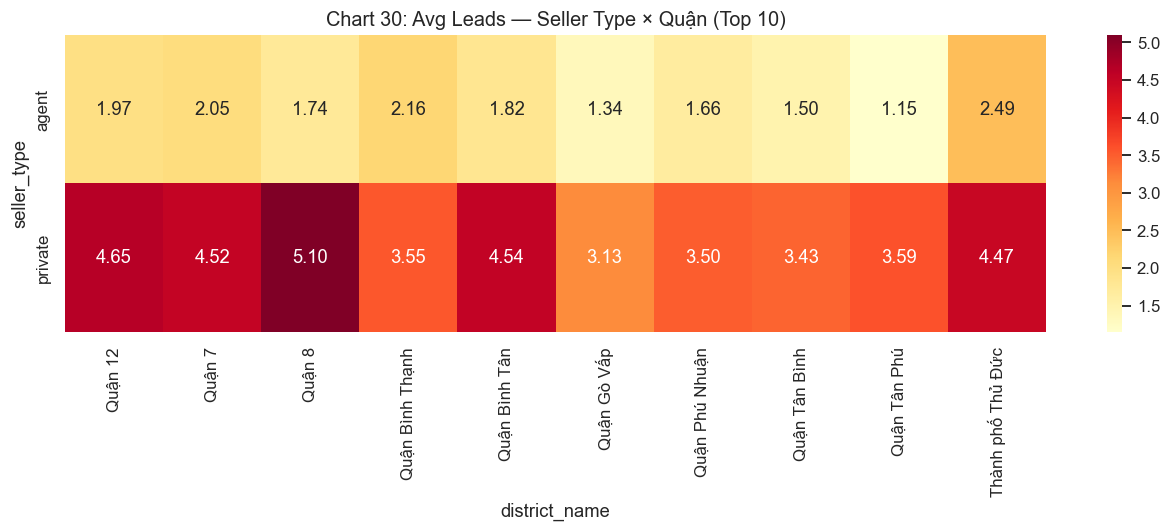

In [82]:
# Chart 30: seller_type x district → avg leads
if top10_dist and 'seller_type' in df_item.columns:
    hm30 = df_item[df_item['district_name'].isin(top10_dist)].groupby(
        ['seller_type','district_name'], observed=True)['n_leads'].mean().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12,5))
    sns.heatmap(hm30, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax)
    ax.set_title('Chart 30: Avg Leads — Seller Type × Quận (Top 10)', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 30 — Seller Type × Quận**: Agency có thể dẫn đầu ở quận trung tâm. Private seller uu the o ngoai o do hieu biet dia phuong.

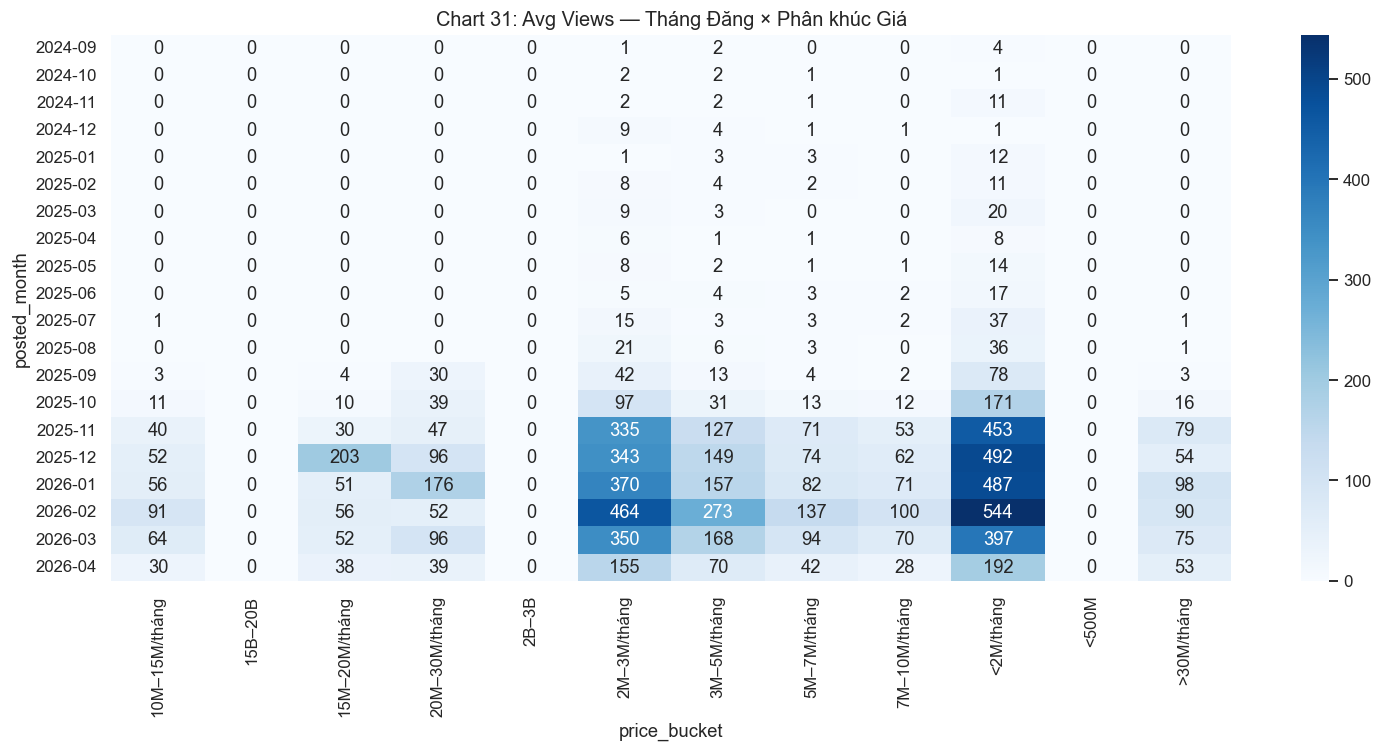

In [83]:
# Chart 31: posted_month x price_bucket → avg views
if 'price_bucket' in df_item.columns and 'posted_month' in df_item.columns:
    hm31 = df_item.groupby(['posted_month','price_bucket'], observed=True)['total_views'].mean().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(14,7))
    sns.heatmap(hm31, annot=True, fmt='.0f', cmap='Blues', ax=ax)
    ax.set_title('Chart 31: Avg Views — Tháng Đăng × Phân khúc Giá', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 31 — Mùa vụ theo Giá**: Thang nao views cao nhat = mùa cao điểm thuê phòng (thang 6-9 sinh vien, 1-2 sau Tet).

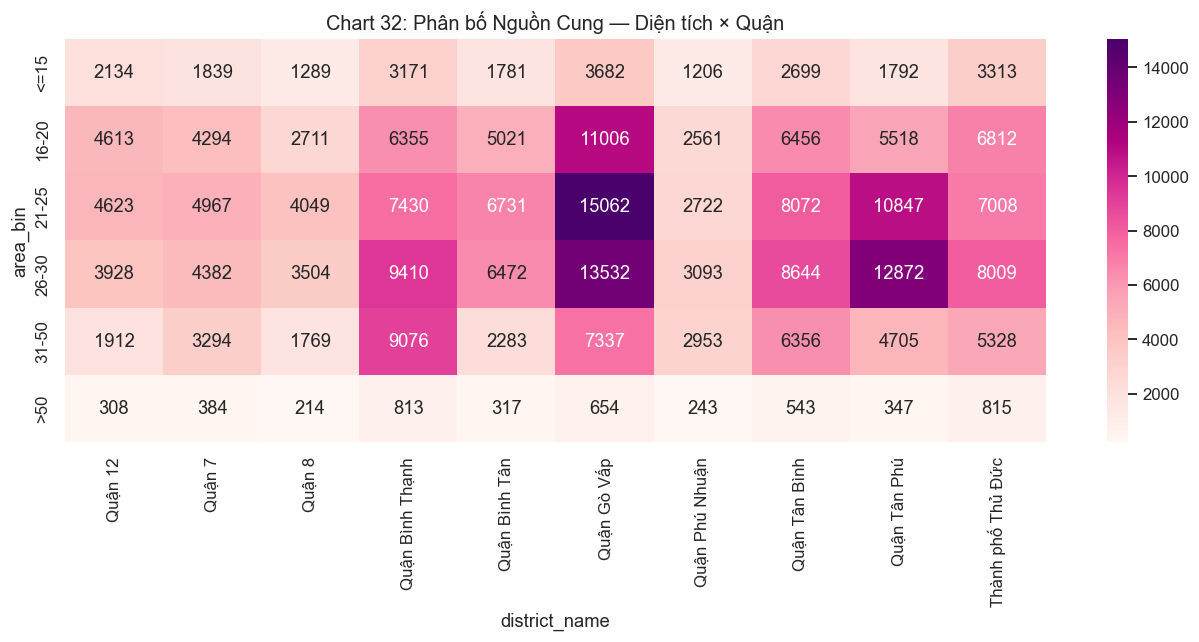

In [84]:
# Chart 32: area_bin x district → listing count
if top10_dist:
    hm32 = df_item[df_item['district_name'].isin(top10_dist)].groupby(
        ['area_bin','district_name'], observed=True)['item_id'].count().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(12,6))
    sns.heatmap(hm32, annot=True, fmt='d', cmap='RdPu', ax=ax)
    ax.set_title('Chart 32: Phân bố Nguồn Cung — Diện tích × Quận', fontsize=13)
    plt.tight_layout(); plt.show()


**Chart 32 — Diện tích × Quận**: Mỗi quận có đặc trưng diện tích phòng riêng rieng. <=15m2 = nha tro mini. 25-30m2 = phòng trọ cao cấp hơn.

---
# Zone 9 — Data Quality & Anomaly (4 charts)

Outlier area >200m²: 842 (0.2%)


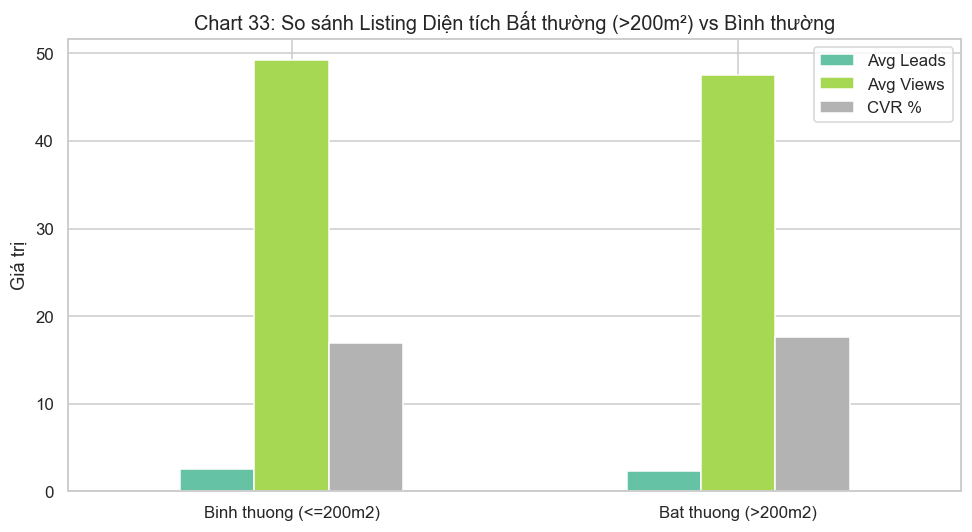

In [85]:
# Chart 33: Outlier area > 200m2
outlier = df_item[df_item['area_sqm'] > 200]
normal  = df_item[df_item['area_sqm'] <= 200]
print(f"Outlier area >200m²: {len(outlier):,} ({len(outlier)/len(df_item)*100:.1f}%)")
cmp33 = pd.DataFrame({
    'Binh thuong (<=200m2)': [normal['n_leads'].mean(), normal['total_views'].mean(), normal['has_lead'].mean()*100],
    'Bat thuong (>200m2)'  : [outlier['n_leads'].mean(), outlier['total_views'].mean(), outlier['has_lead'].mean()*100]
}, index=['Avg Leads','Avg Views','CVR %'])
fig, ax = plt.subplots(figsize=(9,5))
cmp33.T.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_title('Chart 33: So sánh Listing Diện tích Bất thường (>200m²) vs Bình thường', fontsize=13)
ax.set_ylabel('Giá trị'); ax.set_xticklabels(cmp33.T.index, rotation=0)
ax.legend(loc='upper right'); plt.tight_layout(); plt.show()


**Chart 33 — Outlier Diện tích**: Phong tro >200m2 la bat thuong — có thể nhập liệu sai đơn vị. Neu CVR thấp → đây là data noise cần lọc trước khi modeling.

0 anh co leads: 30
                                                         item_id     district_name price_bucket furnishing_clean  n_leads  total_views
cd8f5f97036cddca278ceb11ca5ffaf80ba64787be9528a8f2d5706e4eebaa72            Quận 8    <2M/tháng             Khac      177       1776.0
4618e762c36e9a306722203d1e5337068913fb26670deceab0f13ee9733d53db Thành phố Thủ Đức  3M–5M/tháng             Khac       51       1376.0
1abf7622f07f53b7091e5f56726bd41281e073e374aeb834b5a35fc039d0c113 Thành phố Thủ Đức  3M–5M/tháng             Khac       37        304.0
792d591d986f36a22e137ad16e79310cec5e6bab902849ef40be92a683f43a09       Quận Cẩm Lệ  2M–3M/tháng             Khac       24        615.0
816dd25b9794055a00ae5bd8d3dac83017ae18bb9366a2274447784f4689e79a   Quận Bình Thạnh  2M–3M/tháng             Khac       23        458.0
fc950cbbf0f3ef03833c31ea3698f375735b629c5afe52eab7bd33e386dda63f            Quận 4    <2M/tháng             Khac       21        473.0
6d8df268acb300dd4b59e945da7c46d8d05b

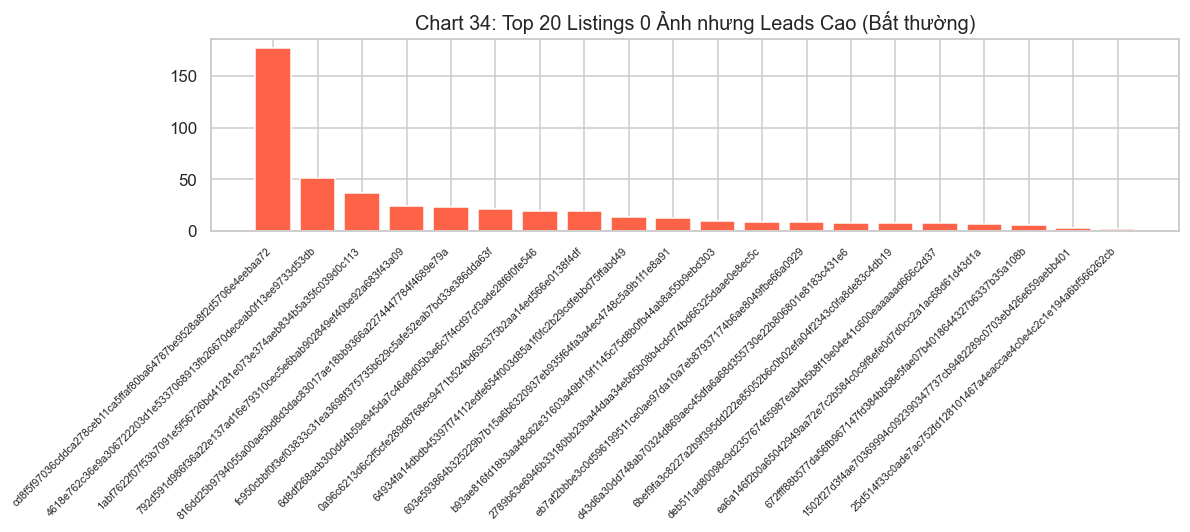

In [86]:
# Chart 34: Anomaly — 0 anh nhung leads cao
an34 = df_item[(df_item['images_count']==0) & (df_item['n_leads']>0)].nlargest(20,'n_leads')
print(f"0 anh co leads: {len(df_item[(df_item['images_count']==0)&(df_item['n_leads']>0)]):,}")
cols34 = [c for c in ['item_id','district_name','price_bucket','furnishing_clean','n_leads','total_views'] if c in df_item.columns]
print(an34[cols34].to_string(index=False))
fig, ax = plt.subplots(figsize=(11,5))
bars34 = ax.bar(range(len(an34)), an34['n_leads'], color='tomato')
ax.set_xticks(range(len(an34)))
ax.set_xticklabels(an34['item_id'].astype(str), rotation=45, ha='right', fontsize=7)
ax.set_title('Chart 34: Top 20 Listings 0 Ảnh nhưng Leads Cao (Bất thường)', fontsize=13)
plt.tight_layout(); plt.show()


**Chart 34 — Anomaly (0 ảnh, nhiều leads)**: Listing 0 ảnh vẫn có leads → gia rat thap, vi tri thuoc loi, hoac seller noi tieng. Anh khong phai yeu to duy nhat quyet dinh leads.

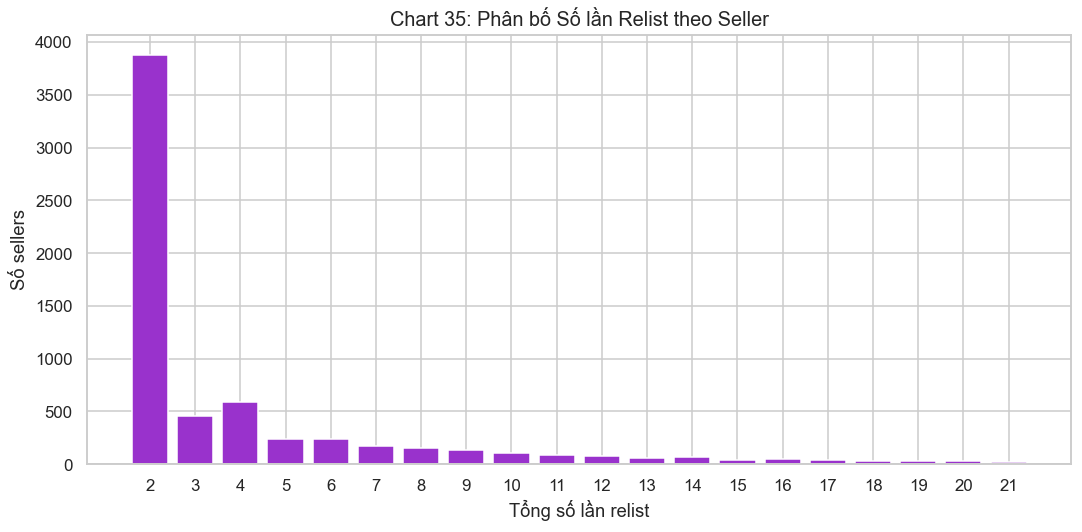

Top 10 sellers relist nhiều nhất:
seller_id
180201831b5daaa4be2c69a1556f411bd2d1a6d1ea8bda303e62406d97a2e9cd    67
0bb3ed53132680e78193bb5e9e2ae0209a9fdf8f9139a2cbe30f1275d029abc9    58
bdec04f466836cac94ba21d7e639ff80b8bd2a8c59717d1bb1b98b9f1f6d20db    54
01244ef6b66585d7ada1a1aee17379821e9ab8168a5846c4821f2b64bb225fc8    50
0243d77508d74afd85ded9974ca3023b7e16a5529351a6b0d8d8ac62cdd0aec9    49
775d3c0109e5b54aede9887ed72e6e2fe77c85c4b135493b4f30a7d459314be9    49
35540d2e15a82a49e79e8011a36b45cc2d3e5cd80dc3149b98f3a28648eca2de    48
547a716d47351891e41ec307e889e3a0c4e38b1f600b94a68ed82f7d7fc3f454    47
9cf3cfaf140f439af4459007bd47dc7d4e8576a34bc552227258089e6b8377c7    47
44c482e0fcd487aa6e8cd52490fadae9664d69dc6f238c8a569054274eb20e28    46
Name: n_list, dtype: int64


In [87]:
# Chart 35: Relist distribution
if 'relist_per_seller' in dir():
    fig, ax = plt.subplots(figsize=(10,5))
    rd = relist_per_seller.value_counts().sort_index().head(20)
    ax.bar(rd.index.astype(str), rd.values, color='darkorchid')
    ax.set_title('Chart 35: Phân bố Số lần Relist theo Seller', fontsize=13)
    ax.set_xlabel('Tổng số lần relist'); ax.set_ylabel('Số sellers')
    plt.tight_layout(); plt.show()
    print("Top 10 sellers relist nhiều nhất:")
    print(relist_per_seller.nlargest(10))
else:
    print("Chạy Chart 28 trước (chua co bien relist_per_seller)")


**Chart 35 — Relisting Distribution**: Đa số sellers relist 1-2 lần là bình thường. Relist >10 lan trong 30 ngay → co the spam.

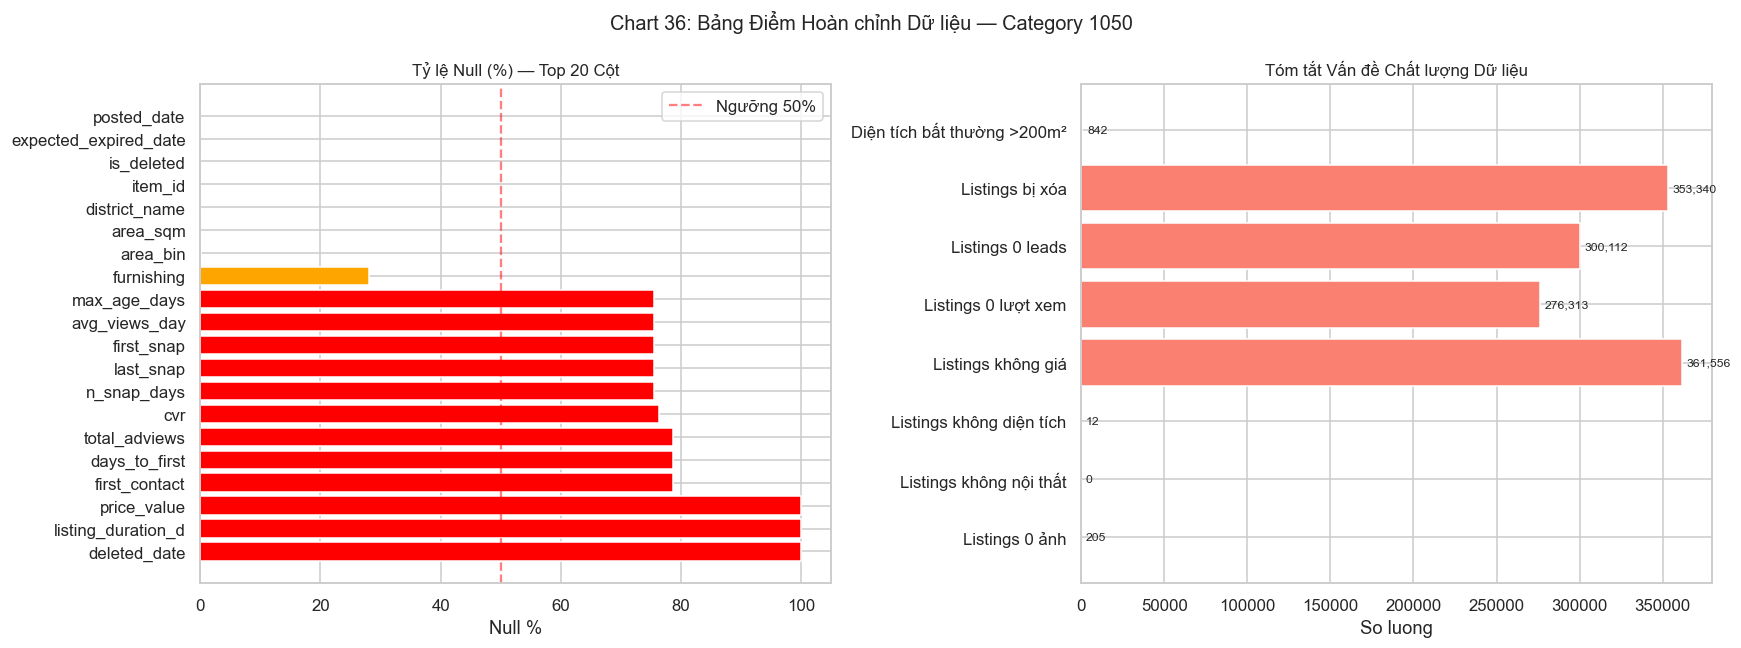


=== TÓM TẮT CHẤT LƯỢNG DỮ LIỆU ===
  Listings 0 ảnh: 205 (0.1%)
  Listings không nội thất: 0 (0.0%)
  Listings không diện tích: 12 (0.0%)
  Listings không giá: 361,556 (100.0%)
  Listings 0 lượt xem: 276,313 (76.4%)
  Listings 0 leads: 300,112 (83.0%)
  Listings bị xóa: 353,340 (97.7%)
  Diện tích bất thường >200m²: 842 (0.2%)


In [88]:
# Chart 36: Data Completeness Scorecard
null_pct = {col: df_item[col].isna().mean()*100 for col in df_item.columns}
null_df = pd.DataFrame.from_dict(null_pct, orient='index', columns=['null_pct']).sort_values('null_pct', ascending=False)

issues = {
    'Listings 0 ảnh'         : int((df_item['images_count']==0).sum()),
    'Listings không nội thất': int((df_item['furnishing_clean']=='Không có').sum()),
    'Listings không diện tích': int(df_item['area_sqm'].isna().sum()),
    'Listings không giá'     : int(df_item['price_value'].isna().sum()) if 'price_value' in df_item.columns else 0,
    'Listings 0 lượt xem'       : int((df_item['total_views']==0).sum()),
    'Listings 0 leads'       : int((df_item['n_leads']==0).sum()),
    'Listings bị xóa'        : int(df_item['is_deleted'].sum()),
    'Diện tích bất thường >200m²'    : int((df_item['area_sqm']>200).sum()),
}

fig, axes = plt.subplots(1,2,figsize=(16,6))
top_null = null_df.head(20)
axes[0].barh(top_null.index,top_null['null_pct'],
             color=['red' if v>50 else 'orange' if v>20 else 'steelblue' for v in top_null['null_pct']])
axes[0].set_title('Tỷ lệ Null (%) — Top 20 Cột', fontsize=11)
axes[0].set_xlabel('Null %')
axes[0].axvline(50, color='red', linestyle='--', alpha=0.5, label='Ngưỡng 50%')
axes[0].legend()

inames = list(issues.keys()); ivals = list(issues.values())
bars36 = axes[1].barh(inames, ivals, color='salmon')
axes[1].set_title('Tóm tắt Vấn đề Chất lượng Dữ liệu', fontsize=11)
axes[1].set_xlabel('So luong')
axes[1].bar_label(bars36, labels=[f'{v:,}' for v in ivals], padding=3, fontsize=8)

fig.suptitle('Chart 36: Bảng Điểm Hoàn chỉnh Dữ liệu — Category 1050', fontsize=13)
plt.tight_layout(); plt.show()

print("\n=== TÓM TẮT CHẤT LƯỢNG DỮ LIỆU ===")
for k,v in issues.items():
    print(f"  {k}: {v:,} ({v/len(df_item)*100:.1f}%)")


**Chart 36 — Scorecard**: Tổng hợp tất cả vấn đề data quality. Cơ sở để đề xuất cải thiện pipeline và hướng dẫn seller.
- Đỏ (>50% null): Vấn đề nghiêm trọng
- Cam (20-50% null): Cần imputation hoặc loại bỏ
- Xanh (<20% null): Chấp nhận được

---
# Kết luận EDA

## Findings chinh
1. **Gia & Dien tich**: Xac dinh phan khuc CVR cao va chênh lệch giá-diện tích
2. **Chat luong Noi dung**: Tieu de 41-60 ky tu va >3 anh tuong quan voi leads cao hon
3. **Seller**: Agency vs Private co profile khac nhau ro rang
4. **Dia ly**: Moi quan dac trung rieng ve noi that, dien tich, CVR
5. **Hanh vi User**: Position bias ro rang; dwell time va login = tin hieu intent tot
6. **Vong doi Listing**: Contact velocity nhanh; listing 0 contact sau 14 ngay co van de
7. **Data Quality**: Nhieu issues can xu ly trước khi modeling

## Buoc tiep theo
- Feature engineering từ cross-dimensional insights
- Model du doan leads dựa trên chất lượng listing
- Phân tích thêm theo mùa vụ và vị trí địa lý